# KF Per-Layer Failure Mode Plots

Per-layer **hole rate** (Mode 1) and **missed-truth-layer rate** (Mode 2),
for both UNMATCHED-only and ALL-GT views, attributed to the best KF attempt of each GT particle.

Data: JSONs produced by `acts/output_examples/attribute_holes_per_layer.py`.


In [31]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt


PARTICLE_COLOR_P1 = {
    "Electron": {"dark": "#0d1f3d", "main": "#3057a0", "light": "#7fa5d4"},
    "Pion":     {"dark": "#6e1c12", "main": "#c0392b", "light": "#e98a7e"},
}


acts_pt_centers_p1 = np.array(eff_data["pt_centers"])
gnn_edges_p1 = np.concatenate([gnn_x - gnn_xerr, [gnn_x[-1] + gnn_xerr[-1]]])

def _rebin_to_gnn(num_arr, den_arr, src_centers):
    n = np.zeros(len(gnn_x), dtype=float)
    d = np.zeros(len(gnn_x), dtype=float)
    for i, c in enumerate(src_centers):
        b = int(np.searchsorted(gnn_edges_p1, c, side="right") - 1)
        if 0 <= b < len(gnn_x):
            n[b] += num_arr[i]
            d[b] += den_arr[i]
    return n, d

PARTICLE_COLOR_P1 = {
    "Electron": {"dark": "#0d1f3d", "main": "#3057a0", "light": "#7fa5d4"},
    "Pion":     {"dark": "#6e1c12", "main": "#c0392b", "light": "#e98a7e"},
}
METHOD_MARKER_P1  = {"seed": "o", "ckf": "s", "gnn": "^"}
MS_P1 = MARKERSIZE + 1


# ── Data dir for ACTS-side JSONs (eff, dropped, attribute_holes, seeding) ─
# Switch this to repoint the whole notebook at a different sample.

DATA_DIR = Path("/data/alice/bkuipers/acts/output_examples/300_mixed_500event")
# DATA_DIR = Path("/data/alice/bkuipers/acts/output_examples/300_new_direction_vector")


#DATA_DIR = Path("/data/alice/bkuipers/acts/output_examples/new_batch500")
# DATA_DIR = Path("/data/alice/bkuipers/acts/output_examples/300_mixed_files")

# ── Path to the directory containing the JSON files ───────────────────────────
PLOT_DIR = Path("/data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/track_metrics/testset_SegmentGNN_GT")

# ── Figure style ──────────────────────────────────────────────────────────────
FIGSIZE      = (7, 5)       # (width, height) in inches
FONT_AXIS    = 18           # axis label font size
FONT_TICK    = 14           # tick label font size
FONT_LEGEND  = 14           # legend font size
FONT_TITLE   = 18           # title font size
CAPSIZE      = 3
MARKERSIZE   = 3 
GRID_ALPHA   = 0.3
DPI          = 150          # set to None to skip saving; otherwise saves next to JSON
AUTO_XLIM    = True         # True: fit x-axis to actual data range; False: use stored xlim

# ── In-plot annotation anchor (axes coords) ─────────────────────────────────
# Move the whole annotation block by editing ANNO_ANCHOR. Set ANNO_HA="right"
# and ANNO_ANCHOR=(0.96, 0.96) for an upper-right placement, etc.
ANNO_ANCHOR  = (0.04, 0.96)  # (x, y) of the top-most line
ANNO_HA      = "left"        # "left" or "right" — text horizontal anchor
ANNO_LINE_DY = 0.07          # vertical spacing between lines (axes-frac)

# ── Segment matching specific ─────────────────────────────────────────────────
MIN_BIN_FRACTION = 0.03     # suppress bins with < this fraction of peak-bin count (segment matching plots only)

print(f"Looking for JSON files in: {PLOT_DIR}")
json_files = sorted(PLOT_DIR.glob("*.json"))
print(f"Found {len(json_files)} file(s):")
for f in json_files:
    print(f"  {f.name}")

Looking for JSON files in: /data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/track_metrics/testset_SegmentGNN_GT
Found 10 file(s):
  clone_rate_vs_eta_testset_SegmentGNN_GT.json
  clone_rate_vs_pt_testset_SegmentGNN_GT.json
  completeness_vs_eta_testset_SegmentGNN_GT.json
  completeness_vs_pt_testset_SegmentGNN_GT.json
  efficiency_vs_eta_testset_SegmentGNN_GT.json
  efficiency_vs_pt_testset_SegmentGNN_GT.json
  matching_efficiency_eta_testset_SegmentGNN_GT.json
  matching_efficiency_pt_testset_SegmentGNN_GT.json
  purity_vs_eta_testset_SegmentGNN_GT.json
  purity_vs_pt_testset_SegmentGNN_GT.json


In [32]:
import re

def none_to_nan(lst):
    """Convert a list with None entries back to a numpy array with np.nan."""
    return np.array([np.nan if v is None else v for v in lst], dtype=float)


def _data_xlim(data: dict, pad_fraction=0.08) -> list:
    """Compute xlim from the actual x ± xerr range across all series."""
    lo, hi = np.inf, -np.inf
    for s in data.get("series", []):
        x    = none_to_nan(s["x"])
        xerr = none_to_nan(s["xerr"])
        valid = ~np.isnan(x) & ~np.isnan(s["y"] if isinstance(s["y"], np.ndarray)
                                          else none_to_nan(s["y"]))
        if not np.any(valid):
            continue
        lo = min(lo, float(np.nanmin(x[valid] - xerr[valid])))
        hi = max(hi, float(np.nanmax(x[valid] + xerr[valid])))
    if not np.isfinite(lo) or not np.isfinite(hi):
        return None
    pad = max((hi - lo) * pad_fraction, 0.02)
    return [lo - pad, hi + pad]


def _apply_min_bin_fraction(s: dict, min_bin_fraction: float) -> dict:
    """Return a copy of series s with sparse bins masked to NaN."""
    if "n" not in s:
        return s
    n = none_to_nan(s["n"])
    peak = np.nanmax(n) if np.any(~np.isnan(n)) else 1
    sparse = n < min_bin_fraction * peak
    y      = none_to_nan(s["y"]).copy()
    ylo    = none_to_nan(s["yerr_lo"]).copy()
    yhi    = none_to_nan(s["yerr_hi"]).copy()
    y[sparse] = np.nan
    ylo[sparse] = np.nan
    yhi[sparse] = np.nan
    return {**s, "y": y, "yerr_lo": ylo, "yerr_hi": yhi}


def render_plot(data: dict, figsize=FIGSIZE, save_path=None,
                min_bin_fraction=None, ylabel_fontsize=None, ylabel=None) -> plt.Figure:
    """Render one plot from its JSON data dict.

    Returns the Figure so the notebook can display or further tweak it.
    ylabel_fontsize overrides FONT_AXIS for the y-axis label only.
    ylabel overrides the label text stored in the JSON.
    """
    fig, ax = plt.subplots(figsize=figsize)

    for s in data.get("series", []):
        if min_bin_fraction is not None:
            s = _apply_min_bin_fraction(s, min_bin_fraction)
        x       = none_to_nan(s["x"])
        xerr    = none_to_nan(s["xerr"])
        y       = none_to_nan(s["y"])
        yerr_lo = none_to_nan(s["yerr_lo"])
        yerr_hi = none_to_nan(s["yerr_hi"])
        label   = re.sub(r"\s*\(.*?\)\s*$", "", s.get("label", ""))

        ax.errorbar(
            x, y,
            xerr=xerr, yerr=[yerr_lo, yerr_hi],
            fmt=s.get("marker", "o"),
            color=s.get("color", None),
            label=label,
            capsize=CAPSIZE, capthick=1.5, markersize=MARKERSIZE,
        )

    ax.set_xlabel(data.get("xlabel", ""), fontsize=FONT_AXIS)
    ax.set_ylabel(ylabel if ylabel is not None else data.get("ylabel", ""),
                  fontsize=ylabel_fontsize if ylabel_fontsize is not None else FONT_AXIS)
    ax.tick_params(axis="both", labelsize=FONT_TICK)
    ax.grid(True, alpha=GRID_ALPHA)
    ax.legend(fontsize=FONT_LEGEND)

    if AUTO_XLIM:
        xlim = _data_xlim(data)
        if xlim is not None:
            ax.set_xlim(xlim)
    elif "xlim" in data and data["xlim"] is not None:
        ax.set_xlim(data["xlim"])

    if "ylim" in data and data["ylim"] is not None:
        ax.set_ylim(data["ylim"])

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig


def load_and_render(json_path: Path, save_suffix="_replot",
                    min_bin_fraction=None, ylabel_fontsize=None, ylabel=None) -> plt.Figure:
    """Load JSON and render. Saves a PDF next to the JSON."""
    with open(json_path) as f:
        data = json.load(f)
    if "title" in data:
        print(data["title"])
    save_path = json_path.with_name(json_path.stem + save_suffix + ".pdf")
    return render_plot(data, save_path=save_path, min_bin_fraction=min_bin_fraction,
                       ylabel_fontsize=ylabel_fontsize, ylabel=ylabel)


print("Helper functions defined.")

Helper functions defined.


Layer thr → dip (muon-driven):
  V13L4   thr=0.108  dip_pT=0.105  eff=0.268
  V13L6   thr=0.150  dip_pT=0.155  eff=0.419
  V13L8   thr=0.198  dip_pT=0.205  eff=0.537
  V17L2   thr=0.246  dip_pT=0.245  eff=0.591
  V17L4   thr=0.306  dip_pT=0.305  eff=0.651
Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/eff_with_dips_replot.pdf


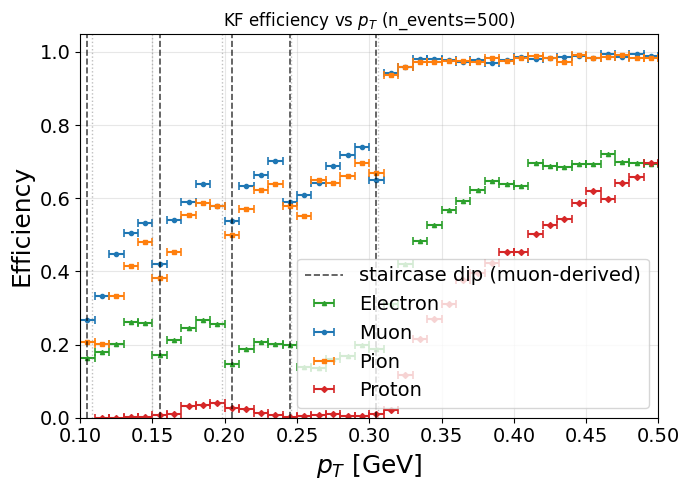

In [33]:
# ── KF efficiency vs pT (all species) + staircase dip detection (muon-only) ──
# Source: acts/output_examples/create_eff_per_particle.py / .C
# Plot efficiency for all 4 species; dips are still derived from the muon
# curve and overlaid as dashed verticals on every per-layer plot below.

EFF_JSON = DATA_DIR / "eff_per_particle.json"

with open(EFF_JSON) as f:
    eff_data = json.load(f)

eff_pt_centers = np.array(eff_data["pt_centers"])
eff_pt_edges   = np.array(eff_data["pt_edges"])

SPECIES_LIST   = ["Electron", "Muon", "Pion", "Proton"]
SPECIES_COLOR  = {"Electron": "#2ca02c", "Muon": "#1f77b4",
                  "Pion": "#ff7f0e", "Proton": "#d62728"}
SPECIES_MARKER = {"Electron": "^", "Muon": "o", "Pion": "s", "Proton": "D"}

eff_by_species = {}
den_by_species = {}
for s in SPECIES_LIST:
    den = np.array(eff_data["den"][s], dtype=float)
    num = np.array(eff_data["num"][s], dtype=float)
    eff_by_species[s] = np.where(den > 0,
                                  num / np.where(den > 0, den, 1), np.nan)
    den_by_species[s] = den

# Muon kept separately — dip detection uses the muon curve only.
mu_den = den_by_species["Muon"]
mu_eff = eff_by_species["Muon"]

# ── Layer geometry (radius in mm) and threshold pT = 0.5 * 0.3 * B * R ──────
B_TESLA = 2.0
LAYER_RADII_MM = {
    "V8L2":   32, "V8L4":   72, "V8L6":  116, "V8L8":  172,
    "V13L2": 260, "V13L4": 360, "V13L6": 500, "V13L8": 660,
    "V17L2": 820, "V17L4": 1020,
}
LAYER_PT_THR = {lay: 0.5 * 0.3 * B_TESLA * (R / 1000.0)
                for lay, R in LAYER_RADII_MM.items()}

# Search range: only layers whose threshold lies in [0.1, 0.35] GeV
PT_LO, PT_HI = 0.10, 0.35
NEIGHBOR_HALF_GEV = 0.020   # ±2 bins (bin width ≈ 0.01 GeV)

dip_layers = sorted(((lay, p) for lay, p in LAYER_PT_THR.items()
                     if PT_LO <= p <= PT_HI),
                    key=lambda kv: kv[1])

# Muon-only dip detection: lowest-eff bin within ±NEIGHBOR_HALF_GEV of each thr.
STAIRCASE_DIPS = []   # (layer, threshold_pt, dip_pt, dip_eff)
for lay, thr in dip_layers:
    in_window = (eff_pt_centers >= thr - NEIGHBOR_HALF_GEV) & \
                (eff_pt_centers <= thr + NEIGHBOR_HALF_GEV)
    eff_in = np.where(in_window, mu_eff, np.nan)
    if np.all(np.isnan(eff_in)):
        continue
    j = int(np.nanargmin(eff_in))
    STAIRCASE_DIPS.append((lay, float(thr), float(eff_pt_centers[j]),
                            float(mu_eff[j])))

STAIRCASE_DIP_PT = [dip_pt for _, _, dip_pt, _ in STAIRCASE_DIPS]
print("Layer thr → dip (muon-driven):")
for lay, thr, dip_pt, dip_eff in STAIRCASE_DIPS:
    print(f"  {lay:6s}  thr={thr:.3f}  dip_pT={dip_pt:.3f}  eff={dip_eff:.3f}")

def overlay_dips(ax, color="black", alpha=0.7, lw=1.2, label=None):
    """Draw dashed verticals at the muon-efficiency staircase dips."""
    for j, p in enumerate(STAIRCASE_DIP_PT):
        ax.axvline(p, color=color, linestyle="--", linewidth=lw, alpha=alpha,
                   zorder=4, label=label if j == 0 else None)

# ── Plot efficiency vs pT for all species ────────────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE)
half_w = 0.5 * (eff_pt_edges[1] - eff_pt_edges[0])
for s in SPECIES_LIST:
    den   = den_by_species[s]
    eff_s = eff_by_species[s]
    valid = den > 0
    ax.errorbar(eff_pt_centers[valid], eff_s[valid], xerr=half_w,
                fmt=SPECIES_MARKER[s], color=SPECIES_COLOR[s],
                markersize=3, capsize=CAPSIZE, capthick=1.2, label=s)
overlay_dips(ax, label="staircase dip (muon-derived)")
for lay, thr in dip_layers:
    ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0, alpha=0.5)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("Efficiency", fontsize=FONT_AXIS)
ax.set_title(f"KF efficiency vs $p_T$ "
             f"(n_events={eff_data.get('n_events','?')})", fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.set_xlim(eff_pt_edges[0], eff_pt_edges[-1])
ax.set_ylim(0.0, 1.05)
ax.grid(True, alpha=GRID_ALPHA)
ax.legend(fontsize=FONT_LEGEND, loc="lower right")
fig.tight_layout()
out = EFF_JSON.parent / "eff_with_dips_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()


## KF vs GNN — Electron efficiency vs $p_T$

Single-species comparison: KF efficiency (from `eff_per_particle.json`, `num["Electron"] / den["Electron"]`) plotted against the GNN segment-matching efficiency loaded from `efficiency_vs_pt_testset_SegmentGNN.json` (electron series).


Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/eff_electron_kf_vs_gnn_replot.pdf


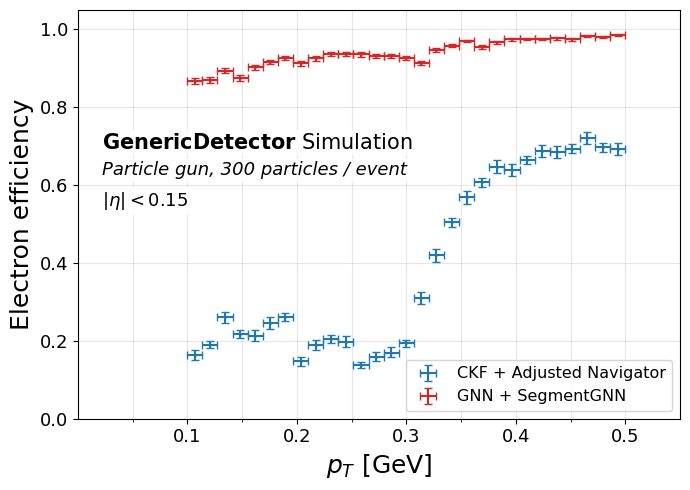

In [34]:
# ── KF vs GNN: electron efficiency vs pT ────────────────────────────────────
# KF: from cell 3 (eff_by_species/den_by_species, eff_pt_centers, eff_pt_edges).
# GNN: load the SegmentGNN efficiency-vs-pT JSON and pick the electron series.

GNN_EFF_JSON = Path(
    "/data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/"
    "track_metrics/testset_SegmentGNN/efficiency_vs_pt_testset_SegmentGNN.json"
)

with open(GNN_EFF_JSON) as f:
    gnn_eff_data = json.load(f)

gnn_electron = next(s for s in gnn_eff_data["series"]
                    if s.get("label", "").startswith("Electron"))
gnn_x       = none_to_nan(gnn_electron["x"])
gnn_xerr    = none_to_nan(gnn_electron["xerr"])
gnn_y       = none_to_nan(gnn_electron["y"])
gnn_yerr_lo = none_to_nan(gnn_electron["yerr_lo"])
gnn_yerr_hi = none_to_nan(gnn_electron["yerr_hi"])

# KF electron raw counts from cell 3
import scipy.stats
kf_num_raw = np.array(eff_data["num"]["Electron"], dtype=float)
kf_den_raw = den_by_species["Electron"]

# Rebin KF counts onto the SegmentGNN x-grid so both curves use the same
# bin width. SegmentGNN bin edges are derived from gnn_x ± gnn_xerr.
gnn_edges = np.concatenate([gnn_x - gnn_xerr, [gnn_x[-1] + gnn_xerr[-1]]])
kf_num = np.zeros(len(gnn_x), dtype=float)
kf_den = np.zeros(len(gnn_x), dtype=float)
for i, c in enumerate(eff_pt_centers):
    b = int(np.searchsorted(gnn_edges, c, side="right") - 1)
    if 0 <= b < len(gnn_x):
        kf_num[b] += kf_num_raw[i]
        kf_den[b] += kf_den_raw[i]
kf_eff_e = np.where(kf_den > 0, kf_num / np.where(kf_den > 0, kf_den, 1), np.nan)
kf_valid = kf_den > 0

# Clopper-Pearson 68% CL — same convention as the SegmentGNN JSON
# (see low_pt_custom_utils/track_evaluation_utils.py::_clopper_pearson_errors).
def _kf_cp_err(passed, total, level=0.68):
    alpha = (1 - level) / 2
    lo = np.where(passed > 0,
                  scipy.stats.beta.ppf(alpha, passed, total - passed + 1), 0.0)
    hi = np.where(passed < total,
                  scipy.stats.beta.ppf(1 - alpha, passed + 1, total - passed), 1.0)
    eff = np.where(total > 0, passed / total, np.nan)
    return np.maximum(0, eff - lo), np.maximum(0, hi - eff)

kf_yerr_lo, kf_yerr_hi = _kf_cp_err(kf_num, kf_den)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.errorbar(gnn_x[kf_valid], kf_eff_e[kf_valid],
            xerr=gnn_xerr[kf_valid],
            yerr=[kf_yerr_lo[kf_valid], kf_yerr_hi[kf_valid]],
            fmt="o", color="#1f77b4",
            markersize=1, capsize=CAPSIZE, capthick=1,
            label="CKF + Adjusted Navigator")
ax.errorbar(gnn_x, gnn_y,
            xerr=gnn_xerr, yerr=[gnn_yerr_lo, gnn_yerr_hi],
            fmt="^", color="#d62728",
            markersize=1, capsize=CAPSIZE, capthick=1,
            label="GNN + SegmentGNN")

ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("Electron efficiency", fontsize=FONT_AXIS)
# ax.set_title(r"Electron efficiency vs $p_T$"
#              "\n"
#              r"(matching fraction 0.7, two-way)",
#              fontsize=FONT_TITLE -1)
ax.tick_params(labelsize=FONT_TICK-1)
ax.set_xlim(0.0, 0.55)
ax.set_xticks(np.arange(0.1, 0.51, 0.1))
ax.set_xticks(np.arange(0.05, 0.51, 0.1), minor=True)
ax.set_ylim(0.0, 1.05)
ax.grid(True, which="both", alpha=GRID_ALPHA)
ax.legend(fontsize=FONT_LEGEND - 2.5, loc="lower right")

# In-plot annotations — anchored via ANNO_ANCHOR / ANNO_HA / ANNO_LINE_DY (cell 1).

ANNO_ANCHOR = (0.04, 0.7)  # (x, y) of the top-most line

_anno_box = dict(facecolor="white", edgecolor="none", alpha=0.85, pad=2)
_ax, _ay = ANNO_ANCHOR
_anno_kw = dict(transform=ax.transAxes, va="top", ha=ANNO_HA, bbox=_anno_box)
ax.text(_ax, _ay,                       r"$\mathbf{Generic Detector}$ Simulation",
        fontsize=FONT_AXIS - 3, **_anno_kw)
# ax.text(_ax, _ay -     ANNO_LINE_DY,    "Generic detector geometry",
#         fontsize=FONT_AXIS - 5, style="italic", **_anno_kw)
ax.text(_ax, _ay -  ANNO_LINE_DY,    "Particle gun, 300 particles / event",
        fontsize=FONT_AXIS - 5, style="italic", **_anno_kw)

ax.text(_ax, _ay - 2 * ANNO_LINE_DY,    r"$|\eta| < 0.15$",
        fontsize=FONT_AXIS - 5, style="italic", **_anno_kw)

fig.tight_layout()
out = EFF_JSON.parent / "eff_electron_kf_vs_gnn_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()


## Triplet Seeding + CKF + GNN — Electrons & Pions

Three reconstruction efficiencies overlaid on a single axis for two species (Electron, Pion):

- **Triplet seeding** — `seeding_eff_per_particle.json` (matched fraction in the seeding stage)
- **Triplet seeding + CKF** — `eff_per_particle.json` (full CKF pipeline, same definition as cell 3)
- **GNN** — `efficiency_vs_pt_testset_SegmentGNN.json` (pipeline + SegmentGNN track building)

ACTS-side curves are rebinned onto the SegmentGNN $p_T$ grid so all curves share bin widths. Errors are Clopper–Pearson 68% CL.
Color = particle (Electron green, Pion orange); marker = method (○ seeding, ■ seeding+CKF, ▲ GNN).


In [35]:
# # ── Triplet seeding + CKF + GNN: Electron & Pion efficiency vs pT ──────────
# # Reuses gnn_eff_data, gnn_x, gnn_xerr, _kf_cp_err, eff_data from cells 3/5.

# SEED_JSON = DATA_DIR / "seeding_eff_per_particle.json"
# with open(SEED_JSON) as f:
#     seed_data = json.load(f)

# acts_pt_centers_p1 = np.array(eff_data["pt_centers"])
# gnn_edges_p1 = np.concatenate([gnn_x - gnn_xerr, [gnn_x[-1] + gnn_xerr[-1]]])

# def _rebin_to_gnn(num_arr, den_arr, src_centers):
#     n = np.zeros(len(gnn_x), dtype=float)
#     d = np.zeros(len(gnn_x), dtype=float)
#     for i, c in enumerate(src_centers):
#         b = int(np.searchsorted(gnn_edges_p1, c, side="right") - 1)
#         if 0 <= b < len(gnn_x):
#             n[b] += num_arr[i]
#             d[b] += den_arr[i]
#     return n, d

# PARTICLE_COLOR_P1 = {
#     "Electron": {"dark": "#0d1f3d", "main": "#3057a0", "light": "#7fa5d4"},
#     "Pion":     {"dark": "#6e1c12", "main": "#c0392b", "light": "#e98a7e"},
# }
# METHOD_MARKER_P1  = {"seed": "o", "ckf": "s", "gnn": "^"}
# MS_P1 = MARKERSIZE + 1

# fig, ax = plt.subplots(figsize=FIGSIZE)
# for species in ["Electron", "Pion"]:
#     palette = PARTICLE_COLOR_P1[species]
#     color_seed = palette["dark"]
#     color_ckf  = palette["main"]
#     color_gnn  = palette["light"]

#     # Triplet seeding (rebinned to GNN grid)
#     n, d = _rebin_to_gnn(np.array(seed_data["num"][species], float),
#                          np.array(seed_data["den"][species], float),
#                          acts_pt_centers_p1)
#     valid = d > 0
#     eff = np.where(valid, n / np.where(valid, d, 1), np.nan)
#     lo, hi = _kf_cp_err(n, d)
#     ax.errorbar(gnn_x[valid], eff[valid],
#                 xerr=gnn_xerr[valid],
#                 yerr=[lo[valid], hi[valid]],
#                 fmt=METHOD_MARKER_P1["seed"], color=color_seed,
#                 markersize=MS_P1, capsize=CAPSIZE, capthick=1,
#                 label=f"{species} — Triplet seeding")

#     # Triplet + CKF (rebinned to GNN grid)
#     n, d = _rebin_to_gnn(np.array(eff_data["num"][species], float),
#                          np.array(eff_data["den"][species], float),
#                          acts_pt_centers_p1)
#     valid = d > 0
#     eff = np.where(valid, n / np.where(valid, d, 1), np.nan)
#     lo, hi = _kf_cp_err(n, d)
#     ax.errorbar(gnn_x[valid], eff[valid],
#                 xerr=gnn_xerr[valid],
#                 yerr=[lo[valid], hi[valid]],
#                 fmt=METHOD_MARKER_P1["ckf"], color=color_ckf,
#                 markersize=MS_P1, capsize=CAPSIZE, capthick=1,
#                 label=f"{species} — Triplet seeding + CKF")

#     # GNN (native SegmentGNN grid)
#     g = next(s for s in gnn_eff_data["series"]
#              if s.get("label", "").startswith(species))
#     gx  = none_to_nan(g["x"])
#     gxe = none_to_nan(g["xerr"])
#     gy  = none_to_nan(g["y"])
#     gyl = none_to_nan(g["yerr_lo"])
#     gyh = none_to_nan(g["yerr_hi"])
#     ax.errorbar(gx, gy, xerr=gxe, yerr=[gyl, gyh],
#                 fmt=METHOD_MARKER_P1["gnn"], color=color_gnn,
#                 markersize=MS_P1, capsize=CAPSIZE, capthick=1,
#                 label=f"{species} — GNN")

# ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
# ax.set_ylabel("Efficiency", fontsize=FONT_AXIS)
# ax.set_xlim(0.0, 0.55)
# ax.set_xticks(np.arange(0.1, 0.51, 0.1))
# ax.set_xticks(np.arange(0.05, 0.51, 0.1), minor=True)
# ax.set_ylim(0.0, 1.05)
# ax.tick_params(labelsize=FONT_TICK - 1)
# ax.grid(True, which='both', alpha=GRID_ALPHA)
# ax.legend(fontsize=FONT_LEGEND - 6, loc="lower right", ncol=1, frameon=False)
# fig.tight_layout()
# out = DATA_DIR / "eff_seeding_ckf_gnn_e_pi_replot.pdf"
# fig.savefig(out, bbox_inches="tight", dpi=DPI)
# print(f"Saved: {out}")
# plt.show()


In [36]:
# # ── Same data as the previous plot, split into Electron | Pion panels ─────
# # Side-by-side subplots so each species has the full y-range to itself.
# # Reuses seed_data, eff_data, gnn_eff_data, _rebin_to_gnn, gnn_x/xerr,
# # acts_pt_centers_p1, PARTICLE_COLOR_P1, METHOD_MARKER_P1, MS_P1 from above.

# fig, axes = plt.subplots(1, 2, figsize=(2 * FIGSIZE[0], FIGSIZE[1]),
#                          sharey=True)
# for ax_p, species in zip(axes, ["Electron", "Pion"]):
#     palette = PARTICLE_COLOR_P1[species]
#     color_seed = palette["dark"]
#     color_ckf  = palette["main"]
#     color_gnn  = palette["light"]

#     # Triplet seeding (rebinned to GNN grid)
#     n, d = _rebin_to_gnn(np.array(seed_data["num"][species], float),
#                          np.array(seed_data["den"][species], float),
#                          acts_pt_centers_p1)
#     valid = d > 0
#     eff = np.where(valid, n / np.where(valid, d, 1), np.nan)
#     lo, hi = _kf_cp_err(n, d)
#     ax_p.errorbar(gnn_x[valid], eff[valid],
#                   xerr=gnn_xerr[valid],
#                   yerr=[lo[valid], hi[valid]],
#                   fmt=METHOD_MARKER_P1["seed"], color=color_seed,
#                   markersize=MS_P1, capsize=CAPSIZE, capthick=1,
#                   label="Triplet seeding")

#     # Triplet + CKF (rebinned to GNN grid)
#     n, d = _rebin_to_gnn(np.array(eff_data["num"][species], float),
#                          np.array(eff_data["den"][species], float),
#                          acts_pt_centers_p1)
#     valid = d > 0
#     eff = np.where(valid, n / np.where(valid, d, 1), np.nan)
#     lo, hi = _kf_cp_err(n, d)
#     ax_p.errorbar(gnn_x[valid], eff[valid],
#                   xerr=gnn_xerr[valid],
#                   yerr=[lo[valid], hi[valid]],
#                   fmt=METHOD_MARKER_P1["ckf"], color=color_ckf,
#                   markersize=MS_P1, capsize=CAPSIZE, capthick=1,
#                   label="Triplet seeding + CKF")

#     # GNN (native SegmentGNN grid)
#     g = next(s for s in gnn_eff_data["series"]
#              if s.get("label", "").startswith(species))
#     gx  = none_to_nan(g["x"])
#     gxe = none_to_nan(g["xerr"])
#     gy  = none_to_nan(g["y"])
#     gyl = none_to_nan(g["yerr_lo"])
#     gyh = none_to_nan(g["yerr_hi"])
#     ax_p.errorbar(gx, gy, xerr=gxe, yerr=[gyl, gyh],
#                   fmt=METHOD_MARKER_P1["gnn"], color=color_gnn,
#                   markersize=MS_P1, capsize=CAPSIZE, capthick=1,
#                   label="GNN + SegmentGNN")

#     ax_p.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
#     ax_p.set_xlim(0.0, 0.55)
#     ax_p.set_xticks(np.arange(0.1, 0.51, 0.1))
#     ax_p.set_xticks(np.arange(0.05, 0.51, 0.1), minor=True)
#     ax_p.set_ylim(0.0, 1.05)
#     ax_p.tick_params(labelsize=FONT_TICK - 1)
#     ax_p.grid(True, which="both", alpha=GRID_ALPHA)
#     ax_p.set_title(species, fontsize=FONT_TITLE - 2)
#     ax_p.legend(fontsize=FONT_LEGEND - 3, loc="lower right", frameon=False)

# axes[0].set_ylabel("Efficiency", fontsize=FONT_AXIS)
# fig.tight_layout()
# out = DATA_DIR / "eff_seeding_ckf_gnn_e_pi_split_replot.pdf"
# fig.savefig(out, bbox_inches="tight", dpi=DPI)
# print(f"Saved: {out}")
# plt.show()


In [37]:
# # ── Same as above, but without Triplet seeding + CKF ──────────────────────
# # Only Triplet seeding and GNN + SegmentGNN are shown.

# fig, axes = plt.subplots(1, 2, figsize=(2 * FIGSIZE[0], FIGSIZE[1]),
#                          sharey=True)
# for ax_p, species in zip(axes, ["Electron", "Pion"]):
#     palette = PARTICLE_COLOR_P1[species]
#     color_seed = palette["dark"]
#     color_gnn  = palette["light"]

#     # Triplet seeding (rebinned to GNN grid)
#     n, d = _rebin_to_gnn(np.array(seed_data["num"][species], float),
#                          np.array(seed_data["den"][species], float),
#                          acts_pt_centers_p1)
#     valid = d > 0
#     eff = np.where(valid, n / np.where(valid, d, 1), np.nan)
#     lo, hi = _kf_cp_err(n, d)
#     ax_p.errorbar(gnn_x[valid], eff[valid],
#                   xerr=gnn_xerr[valid],
#                   yerr=[lo[valid], hi[valid]],
#                   fmt=METHOD_MARKER_P1["seed"], color=color_seed,
#                   markersize=MS_P1, capsize=CAPSIZE, capthick=1,
#                   label="Triplet seeding")

#     # GNN (native SegmentGNN grid)
#     g = next(s for s in gnn_eff_data["series"]
#              if s.get("label", "").startswith(species))
#     gx  = none_to_nan(g["x"])
#     gxe = none_to_nan(g["xerr"])
#     gy  = none_to_nan(g["y"])
#     gyl = none_to_nan(g["yerr_lo"])
#     gyh = none_to_nan(g["yerr_hi"])
#     ax_p.errorbar(gx, gy, xerr=gxe, yerr=[gyl, gyh],
#                   fmt=METHOD_MARKER_P1["gnn"], color=color_gnn,
#                   markersize=MS_P1, capsize=CAPSIZE, capthick=1,
#                   label="GNN + SegmentGNN")

#     ax_p.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
#     ax_p.set_xlim(0.0, 0.55)
#     ax_p.set_xticks(np.arange(0.1, 0.51, 0.1))
#     ax_p.set_xticks(np.arange(0.05, 0.51, 0.1), minor=True)
#     ax_p.set_ylim(0.0, 1.05)
#     ax_p.tick_params(labelsize=FONT_TICK - 1)
#     ax_p.grid(True, which="both", alpha=GRID_ALPHA)
#     ax_p.set_title(species, fontsize=FONT_TITLE - 2)
#     ax_p.legend(fontsize=FONT_LEGEND - 3, loc="lower right", frameon=False)

# axes[0].set_ylabel("Efficiency", fontsize=FONT_AXIS)

# # In-plot annotations — anchored via ANNO_HA / ANNO_LINE_DY (cell 1).
# ANNO_ANCHOR = (0.04, 0.25)  # (x, y) of the top-most line

# _anno_box = dict(facecolor="white", edgecolor="none", alpha=0.85, pad=2)
# _ax, _ay = ANNO_ANCHOR
# _anno_kw = dict(transform=axes[0].transAxes, va="top", ha=ANNO_HA, bbox=_anno_box)
# axes[0].text(_ax, _ay,                       r"$\mathbf{ODD}$ Simulation",
#         fontsize=FONT_AXIS - 3, **_anno_kw)
# # axes[0].text(_ax, _ay -     ANNO_LINE_DY,    "Generic detector geometry",
# #         fontsize=FONT_AXIS - 5, style="italic", **_anno_kw)
# axes[0].text(_ax, _ay -  ANNO_LINE_DY,    "Particle gun, 300 particles / event",
#         fontsize=FONT_AXIS - 5, style="italic", **_anno_kw)

# axes[0].text(_ax, _ay - 2 * ANNO_LINE_DY,    r"$|\eta| < 0.15$",
#         fontsize=FONT_AXIS - 5, style="italic", **_anno_kw)

# fig.tight_layout()
# out = DATA_DIR / "eff_seeding_gnn_e_pi_split_replot.pdf"
# fig.savefig(out, bbox_inches="tight", dpi=DPI)
# print(f"Saved: {out}")
# plt.show()


## Triplet Seeding + CKF vs Truth Smearing + CKF — Electrons & Pions

Compares two CKF configurations using the same `eff_per_particle.json` schema:

- **Triplet seeding + CKF** — `300_new_direction_vector/eff_per_particle.json`
- **Truth smearing + CKF** — `300_new_direction_vector_truth/eff_per_particle.json`

Both curves share the native ACTS 40-bin $p_T$ grid (no rebinning needed). Errors are Clopper–Pearson 68% CL.
Color = particle (Electron green, Pion orange); marker = method (■ Triplet+CKF filled, ◇ Truth+CKF hollow).


Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/eff_triplet_vs_truth_ckf_e_pi_replot.pdf


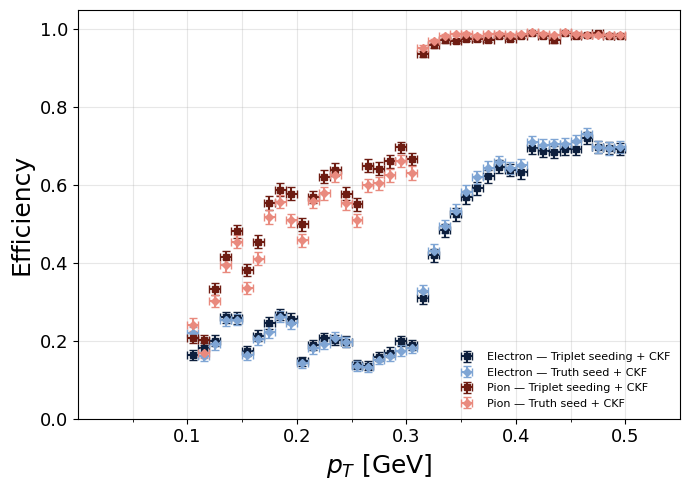

In [38]:
# ── Triplet seeding + CKF vs Truth smearing + CKF: Electron & Pion ─────────
# Both JSONs follow the same schema as eff_per_particle.json.

TRUTH_JSON = Path(
    "/data/alice/bkuipers/acts/output_examples/300_new_direction_vector_truth/"
    "eff_per_particle.json"
)
with open(TRUTH_JSON) as f:
    truth_data = json.load(f)

acts_pt_centers_p2 = np.array(eff_data["pt_centers"])
acts_pt_edges_p2   = np.array(eff_data["pt_edges"])
half_w_p2 = 0.5 * (acts_pt_edges_p2[1] - acts_pt_edges_p2[0])

PARTICLE_COLOR_P2 = {
    "Electron": {"triplet": "#0d1f3d", "truth": "#7fa5d4"},
    "Pion":     {"triplet": "#6e1c12", "truth": "#e98a7e"},
}
# (label, source, marker, palette key) — palette key picks a per-species shade.
METHODS_P2 = [
    ("Triplet seeding + CKF", eff_data,   "s", "triplet"),
    ("Truth seed + CKF",  truth_data, "D", "truth"),
]

fig, ax = plt.subplots(figsize=FIGSIZE)
for species in ["Electron", "Pion"]:
    for label, src, marker, key in METHODS_P2:
        color = PARTICLE_COLOR_P2[species][key]
        n = np.array(src["num"][species], dtype=float)
        d = np.array(src["den"][species], dtype=float)
        valid = d > 0
        eff = np.where(valid, n / np.where(valid, d, 1), np.nan)
        lo, hi = _kf_cp_err(n, d)
        ax.errorbar(acts_pt_centers_p2[valid], eff[valid],
                    xerr=half_w_p2,
                    yerr=[lo[valid], hi[valid]],
                    fmt=marker, color=color,
                    markersize=MARKERSIZE + 1, capsize=CAPSIZE, capthick=1,
                    label=f"{species} — {label}")

ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("Efficiency", fontsize=FONT_AXIS)
ax.set_xlim(0.0, 0.55)
ax.set_xticks(np.arange(0.1, 0.51, 0.1))
ax.set_xticks(np.arange(0.05, 0.51, 0.1), minor=True)
ax.set_ylim(0.0, 1.05)
ax.tick_params(labelsize=FONT_TICK - 1)
ax.grid(True, which='both', alpha=GRID_ALPHA)
ax.legend(fontsize=FONT_LEGEND - 6, loc="lower right", ncol=1, frameon=False)
fig.tight_layout()
out = DATA_DIR / "eff_triplet_vs_truth_ckf_e_pi_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()


## KF Failure Modes — UNMATCHED GT Only (per-layer attribution)

Re-attribution of holes & missed-truth-layers using only the **best KF attempt of GT particles that ended up unmatched**. This filters out holes belonging to tracks that still successfully reconstructed their particle (which inflated the original `kf_failure_modes.json` plots).

Theoretical layer thresholds $p_T = 0.15 \cdot B \cdot R$ (B = 2 T) overlaid as triangles on the x-axis.

Data produced by `acts/output_examples/attribute_holes_per_layer.py` (30 events) and saved to `attribute_holes_per_layer.json`.


Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_holes_unmatched_muon_replot.pdf


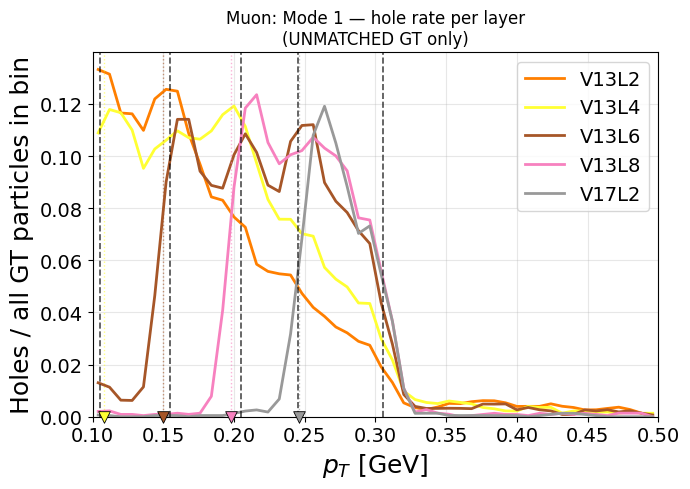

/tmp/ipykernel_282540/4205769511.py:58: RuntimeWarning: invalid value encountered in divide
  out = np.where(den > 0, num / den, np.nan)


Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_misses_unmatched_muon_replot.pdf


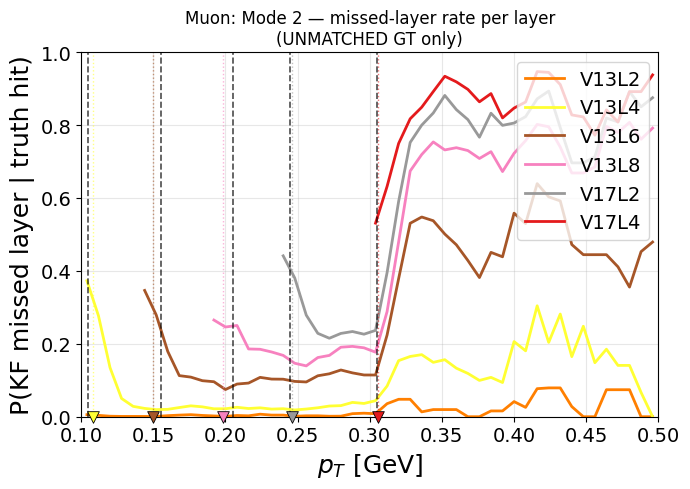

In [39]:
ATTR_JSON = DATA_DIR / "attribute_holes_per_layer.json"

with open(ATTR_JSON) as f:
    attr = json.load(f)

pt_centers = np.array(attr["pt_centers"])
pt_edges   = np.array(attr["pt_edges"])

# Layer (V, L) -> radius [mm], from detector geometry figure
LAYER_RADIUS_MM = {
    ("V8",  "L2"):  32, ("V8",  "L4"):  72, ("V8",  "L6"): 116, ("V8",  "L8"): 172,
    ("V13", "L2"): 260, ("V13", "L4"): 360, ("V13", "L6"): 500, ("V13", "L8"): 660,
    ("V17", "L2"): 820, ("V17", "L4"): 1020,
}
B_TESLA = 2.0

def layer_threshold(lay):
    i = lay.index("L"); key = (lay[:i], lay[i:])
    if key not in LAYER_RADIUS_MM:
        return None
    return 0.5 * 0.3 * B_TESLA * (LAYER_RADIUS_MM[key] / 1000.0)

def layer_radius(lay):
    i = lay.index("L"); return LAYER_RADIUS_MM.get((lay[:i], lay[i:]), 9999)

LAYER_CMAP   = plt.get_cmap("Set1")
PEAK_THRESH  = 0.05    # show layers whose unmatched-hole rate peaks above this
SKIP_VOLUMES = {"V8", "V9"}  # skip pixel layers (thresholds 0.01-0.05 GeV are below pT range)
SKIP_LAYERS  = {"V7L14"}     # skip specific volume+layer combos
SMOOTH_WIN   = 3       # rolling-mean window for line smoothing (set 1 to disable)

def _keep_layer(lay):
    return lay[:lay.index("L")] not in SKIP_VOLUMES and lay not in SKIP_LAYERS

# Stable layer -> color map: order layers by radius, assign deterministic colors
# so the same layer always gets the same color across all plots.
LAYER_COLOR = {
    f"{v}{l}": LAYER_CMAP(i % 9)
    for i, (v, l) in enumerate(sorted(LAYER_RADIUS_MM.keys(),
                                      key=lambda k: LAYER_RADIUS_MM[k]))
}

def layer_color(lay):
    return LAYER_COLOR.get(lay, "black")

def smooth(y, w):
    if w <= 1:
        return y
    valid = ~np.isnan(y)
    if valid.sum() < w:
        return y
    pad = w // 2
    yy  = np.where(valid, y, 0.0)
    ww  = valid.astype(float)
    kernel = np.ones(w) / w
    num = np.convolve(yy, kernel, mode="same")
    den = np.convolve(ww, kernel, mode="same")
    out = np.where(den > 0, num / den, np.nan)
    out[~valid] = np.nan
    return out

for species in ["Muon"]:
    n_total = np.array(attr["n_total"][species])
    mask    = n_total > 0

    # ── Mode 1: hole rate (UNMATCHED GT only) ────────────────────────────────
    fig, ax = plt.subplots(figsize=FIGSIZE)
    layers  = sorted(attr["holes_unmatched"][species].keys(), key=layer_radius)
    layers  = [l for l in layers if _keep_layer(l)]
    for lay in layers:
        holes = np.array(attr["holes_unmatched"][species][lay])
        rate  = np.where(mask, holes / np.where(mask, n_total, 1), np.nan)
        if np.nanmax(rate) < PEAK_THRESH:
            continue
        color = layer_color(lay)
        ax.plot(pt_centers, smooth(rate, SMOOTH_WIN), "-", color=color,
                linewidth=2, label=lay)
        thr = layer_threshold(lay)
        if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
            ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.6)
            ax.scatter([thr], [0.0], marker="v", color=color,
                       s=70, zorder=5, edgecolor="black", linewidth=0.6,
                       clip_on=False)
    overlay_dips(ax)
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("Holes / all GT particles in bin", fontsize=FONT_AXIS)
    ax.set_title(f"{species}: Mode 1 — hole rate per layer\n(UNMATCHED GT only)",
                 fontsize=12)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(pt_edges[0], pt_edges[-1])
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    out = ATTR_JSON.parent / f"attribute_holes_unmatched_{species.lower()}_replot.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()

    # ── Mode 2: conditional missed-layer rate (UNMATCHED only) ───────────────
    fig, ax = plt.subplots(figsize=FIGSIZE)
    layers  = sorted(attr["miss_den_unmatched"][species].keys(), key=layer_radius)
    layers  = [l for l in layers if _keep_layer(l)]
    for lay in layers:
        zeros = [0.0] * len(pt_centers)
        num  = np.array(attr["miss_num_unmatched"][species].get(lay, zeros))
        den  = np.array(attr["miss_den_unmatched"][species].get(lay, zeros))
        m    = den > 0
        rate = np.where(m, num / np.where(m, den, 1), np.nan)
        if np.nanmax(rate) < PEAK_THRESH:
            continue
        color = layer_color(lay)
        ax.plot(pt_centers, smooth(rate, SMOOTH_WIN), "-", color=color,
                linewidth=2, label=lay)
        thr = layer_threshold(lay)
        if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
            ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.6)
            ax.scatter([thr], [0.0], marker="v", color=color,
                       s=70, zorder=5, edgecolor="black", linewidth=0.6,
                       clip_on=False)
    overlay_dips(ax)
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("P(KF missed layer | truth hit)", fontsize=FONT_AXIS)
    ax.set_title(f"{species}: Mode 2 — missed-layer rate per layer\n(UNMATCHED GT only)",
                 fontsize=12)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(pt_edges[0], pt_edges[-1])
    ax.set_ylim(0, 1)
    fig.tight_layout()
    out = ATTR_JSON.parent / f"attribute_misses_unmatched_{species.lower()}_replot.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()


## KF Failure Modes — ALL GT (per-layer, line plot)

Same per-layer attribution but using the **best KF attempt of every GT particle with at least one attempt** — no matched/unmatched filter. Companion to the UNMATCHED-only view above. Generated alongside the unmatched JSON in a single pass by `attribute_holes_per_layer.py` (same MAX_EVENTS / N_BINS).


Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_holes_all_gt_muon_replot.pdf


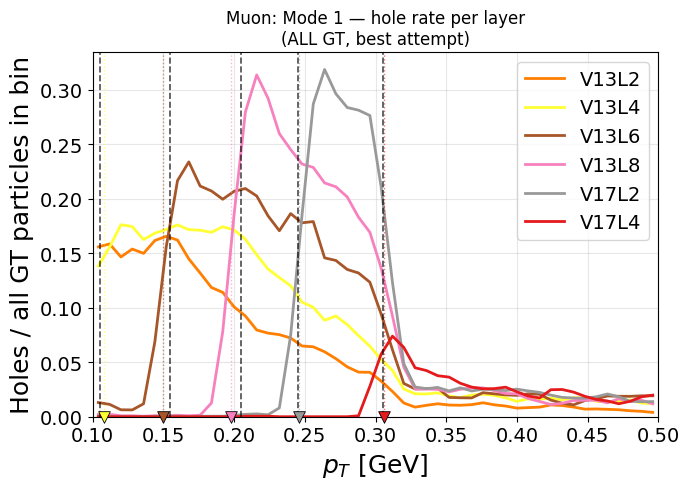

/tmp/ipykernel_282540/4205769511.py:58: RuntimeWarning: invalid value encountered in divide
  out = np.where(den > 0, num / den, np.nan)


Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_misses_all_gt_muon_replot.pdf


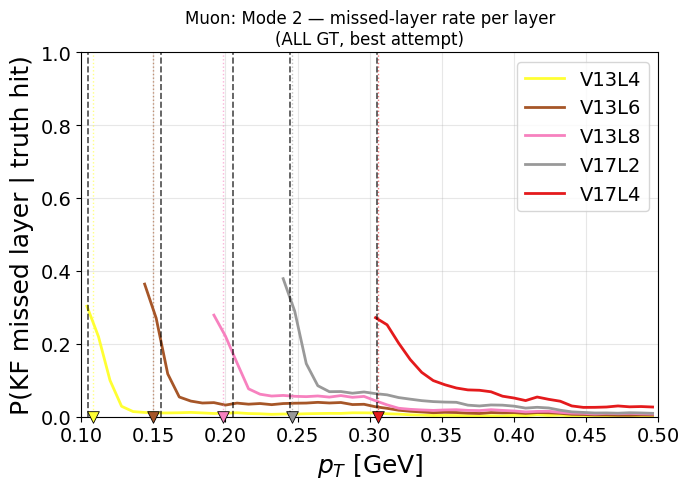

In [40]:
ALL_JSON = DATA_DIR / "attribute_holes_per_layer_all_gt.json"

with open(ALL_JSON) as f:
    allgt = json.load(f)

pt_centers = np.array(allgt["pt_centers"])
pt_edges   = np.array(allgt["pt_edges"])

# (Re-use LAYER_RADIUS_MM, B_TESLA, layer_threshold, layer_radius, smooth, _keep_layer,
#  layer_color from the cell above.)
SKIP_VOLUMES = {"V8", "V9"}  # skip pixel layers (thresholds 0.01-0.05 GeV are below pT range)
SKIP_LAYERS  = {"V7L14"}     # skip specific volume+layer combos
PEAK_THRESH  = 0.05
SMOOTH_WIN   = 3
LAYER_CMAP   = plt.get_cmap("Set1")

def _keep_layer(lay):
    return lay[:lay.index("L")] not in SKIP_VOLUMES and lay not in SKIP_LAYERS

for species in ["Muon"]:
    n_total = np.array(allgt["n_total"][species])
    mask    = n_total > 0

    # ── Mode 1: hole rate (ALL GT, best attempt) ─────────────────────────────
    fig, ax = plt.subplots(figsize=FIGSIZE)
    layers  = sorted(allgt["holes_all"][species].keys(), key=layer_radius)
    layers  = [l for l in layers if _keep_layer(l)]
    for lay in layers:
        holes = np.array(allgt["holes_all"][species][lay])
        rate  = np.where(mask, holes / np.where(mask, n_total, 1), np.nan)
        if np.nanmax(rate) < PEAK_THRESH:
            continue
        color = layer_color(lay)
        ax.plot(pt_centers, smooth(rate, SMOOTH_WIN), "-", color=color,
                linewidth=2, label=lay)
        thr = layer_threshold(lay)
        if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
            ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.6)
            ax.scatter([thr], [0.0], marker="v", color=color,
                       s=70, zorder=5, edgecolor="black", linewidth=0.6,
                       clip_on=False)
    overlay_dips(ax)
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("Holes / all GT particles in bin", fontsize=FONT_AXIS)
    ax.set_title(f"{species}: Mode 1 — hole rate per layer\n(ALL GT, best attempt)",
                 fontsize=12)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(pt_edges[0], pt_edges[-1])
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    out = ALL_JSON.parent / f"attribute_holes_all_gt_{species.lower()}_replot.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()

    # ── Mode 2: conditional missed-layer rate (ALL GT) ───────────────────────
    fig, ax = plt.subplots(figsize=FIGSIZE)
    layers  = sorted(allgt["miss_den_all"][species].keys(), key=layer_radius)
    layers  = [l for l in layers if _keep_layer(l)]
    for lay in layers:
        zeros = [0.0] * len(pt_centers)
        num  = np.array(allgt["miss_num_all"][species].get(lay, zeros))
        den  = np.array(allgt["miss_den_all"][species].get(lay, zeros))
        m    = den > 0
        rate = np.where(m, num / np.where(m, den, 1), np.nan)
        if np.nanmax(rate) < PEAK_THRESH:
            continue
        color = layer_color(lay)
        ax.plot(pt_centers, smooth(rate, SMOOTH_WIN), "-", color=color,
                linewidth=2, label=lay)
        thr = layer_threshold(lay)
        if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
            ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.6)
            ax.scatter([thr], [0.0], marker="v", color=color,
                       s=70, zorder=5, edgecolor="black", linewidth=0.6,
                       clip_on=False)
    overlay_dips(ax)
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("P(KF missed layer | truth hit)", fontsize=FONT_AXIS)
    ax.set_title(f"{species}: Mode 2 — missed-layer rate per layer\n(ALL GT, best attempt)",
                 fontsize=12)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(pt_edges[0], pt_edges[-1])
    ax.set_ylim(0, 1)
    fig.tight_layout()
    out = ALL_JSON.parent / f"attribute_misses_all_gt_{species.lower()}_replot.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()


## KF Failure Modes — Layer-accumulated (per species)

Sum across all kept layers (respects `SKIP_VOLUMES` / `SKIP_LAYERS`) to give the total per-particle failure rate vs $p_T$.

- **Mode 1 (holes):** $\sum_\ell \text{holes}_\ell\,/\,N_\text{tot}$ — average number of holes per GT particle.
- **Mode 2 (missed layers):** $\sum_\ell \text{miss\_num}_\ell\,/\,\sum_\ell \text{miss\_den}_\ell$ — pooled probability that a truth-hit layer was missed.

Both UNMATCHED-only and ALL-GT views are shown side-by-side.


Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_holes_unmatched_accumulated_replot.pdf


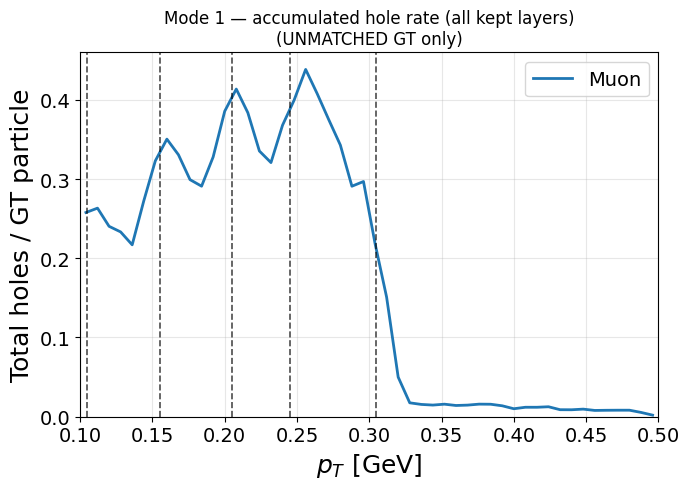

Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_holes_all_gt_accumulated_replot.pdf


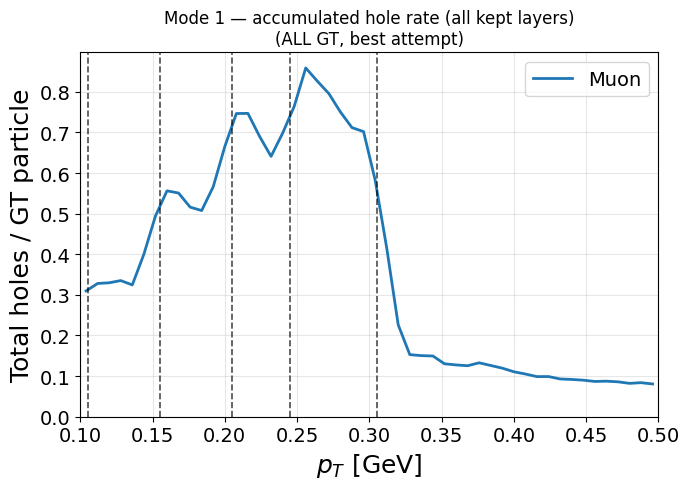

Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_misses_unmatched_accumulated_replot.pdf


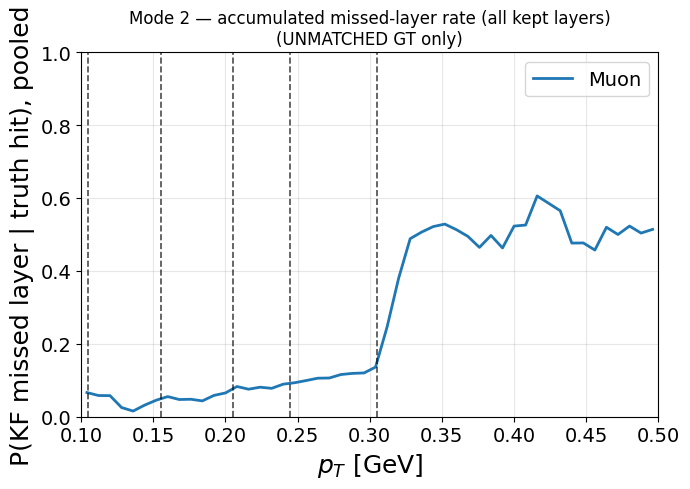

Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_misses_all_gt_accumulated_replot.pdf


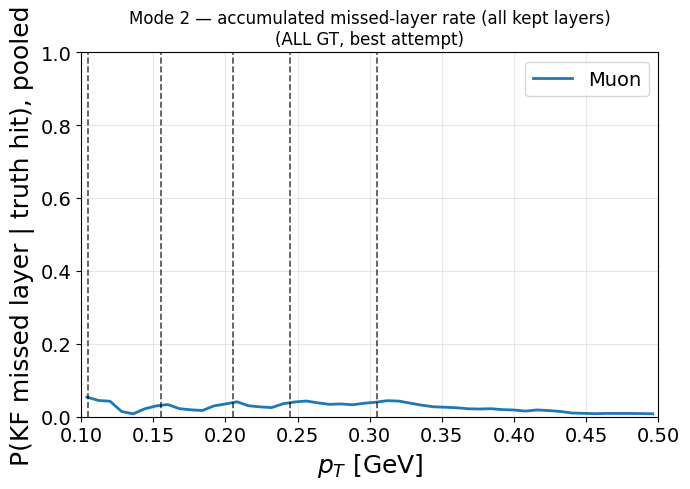

In [41]:
# Layer-accumulated KF failure-mode plots.
# Uses attr (UNMATCHED) and allgt (ALL GT) loaded above, same pt_centers/pt_edges,
# same SKIP_VOLUMES / SKIP_LAYERS / _keep_layer / smooth.

SPECIES_COLOR = {"Muon": "C0", "Pion": "C3"}

def _accumulate_holes(d, species, n_total, mask):
    """Sum holes across kept layers; return rate = total_holes / n_total."""
    layers = [l for l in d[species].keys() if _keep_layer(l)]
    total = np.zeros_like(n_total, dtype=float)
    for lay in layers:
        total += np.array(d[species][lay], dtype=float)
    return np.where(mask, total / np.where(mask, n_total, 1), np.nan)

def _accumulate_misses(num_d, den_d, species):
    """Pool numerator/denominator across kept layers; return num/den."""
    layers = [l for l in den_d[species].keys() if _keep_layer(l)]
    num = np.zeros_like(pt_centers, dtype=float)
    den = np.zeros_like(pt_centers, dtype=float)
    zeros = [0.0] * len(pt_centers)
    for lay in layers:
        num += np.array(num_d[species].get(lay, zeros), dtype=float)
        den += np.array(den_d[species].get(lay, zeros), dtype=float)
    m = den > 0
    return np.where(m, num / np.where(m, den, 1), np.nan)

# ── Mode 1 accumulated: holes per particle ───────────────────────────────────
for view, src, tag in [("UNMATCHED GT only", attr,  "unmatched"),
                       ("ALL GT, best attempt", allgt, "all_gt")]:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    holes_key = "holes_unmatched" if tag == "unmatched" else "holes_all"
    for species in ["Muon"]:
        n_total = np.array(src["n_total"][species])
        mask    = n_total > 0
        rate = _accumulate_holes(src[holes_key], species, n_total, mask)
        ax.plot(pt_centers, smooth(rate, SMOOTH_WIN), "-",
                color=SPECIES_COLOR[species], linewidth=2, label=species)
    overlay_dips(ax)
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("Total holes / GT particle", fontsize=FONT_AXIS)
    ax.set_title(f"Mode 1 — accumulated hole rate (all kept layers)\n({view})",
                 fontsize=12)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, loc="upper right")
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(pt_edges[0], pt_edges[-1])
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    out = ATTR_JSON.parent / f"attribute_holes_{tag}_accumulated_replot.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()

# ── Mode 2 accumulated: pooled missed-layer probability ──────────────────────
for view, src, tag in [("UNMATCHED GT only", attr,  "unmatched"),
                       ("ALL GT, best attempt", allgt, "all_gt")]:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    num_key = "miss_num_unmatched" if tag == "unmatched" else "miss_num_all"
    den_key = "miss_den_unmatched" if tag == "unmatched" else "miss_den_all"
    for species in ["Muon"]:
        rate = _accumulate_misses(src[num_key], src[den_key], species)
        ax.plot(pt_centers, smooth(rate, SMOOTH_WIN), "-",
                color=SPECIES_COLOR[species], linewidth=2, label=species)
    overlay_dips(ax)
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("P(KF missed layer | truth hit), pooled", fontsize=FONT_AXIS)
    ax.set_title(f"Mode 2 — accumulated missed-layer rate (all kept layers)\n({view})",
                 fontsize=12)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, loc="upper right")
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(pt_edges[0], pt_edges[-1])
    ax.set_ylim(0, 1)
    fig.tight_layout()
    out = ATTR_JSON.parent / f"attribute_misses_{tag}_accumulated_replot.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()


## Absolute-count view (Muon, ALL GT)

The Mode 2 ratio `miss_num / miss_den` is conditional on a layer being truly hit, so a low denominator
(few particles even reach the layer in that pT bin) inflates the ratio. To check whether the staircase
dips line up with the actual *number* of failures, plot the raw numerator counts straight from the JSON:

- **Mode 1 abs:** total holes per layer per pT bin — `holes_all[Muon][lay][b]` (no normalisation).
- **Mode 2 abs:** number of GT muon particles whose truth hit on a layer was missed by the KF — `miss_num_all[Muon][lay][b]`.

Dashed verticals are the staircase dips from cell 3.

Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_holes_all_gt_muon_absolute_replot.pdf


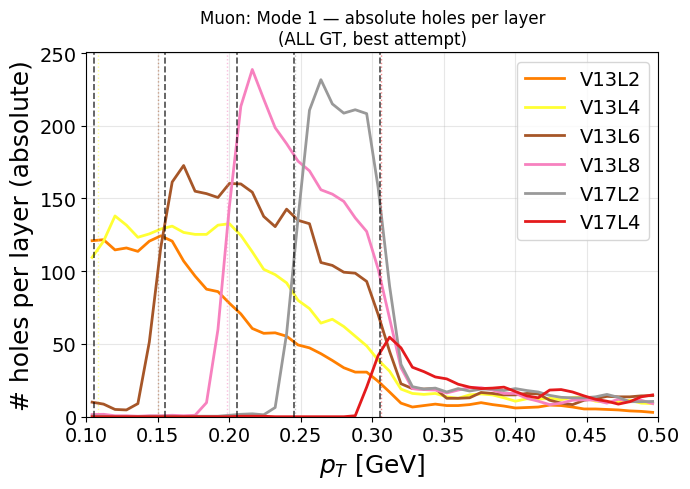

Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_misses_all_gt_muon_absolute_replot.pdf


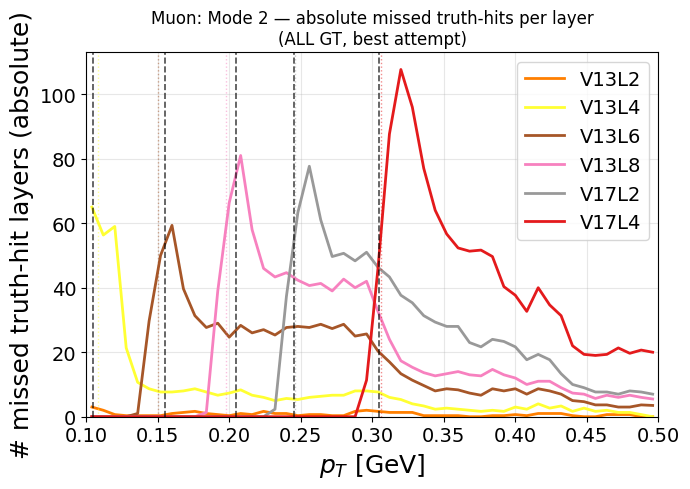

Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_miss_denom_all_gt_muon_replot.pdf


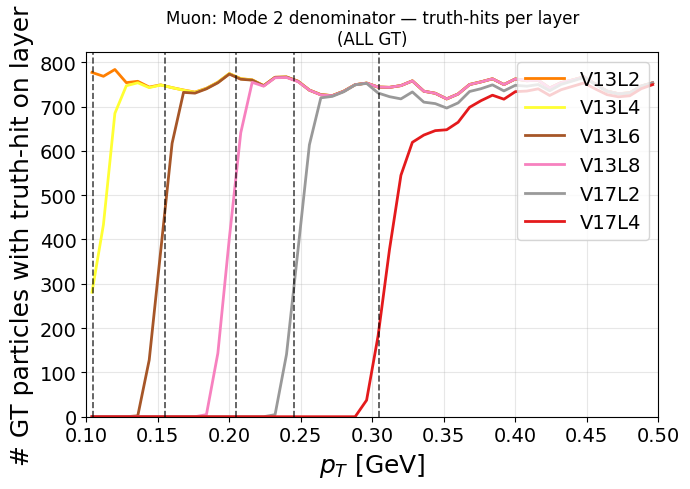

In [42]:
# ── Absolute counts per layer (Muon, ALL GT) ────────────────────────────────
# Plots the raw JSON numerators (no rate normalisation), so the y-axis reflects
# how many failures actually occurred in each pT bin × layer cell.

species = "Muon"
PEAK_THRESH_ABS = 1.0   # show layers whose absolute peak count is at least this

# ── Mode 1 absolute: total holes per layer ──────────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE)
layers = sorted(allgt["holes_all"][species].keys(), key=layer_radius)
layers = [l for l in layers if _keep_layer(l)]
for lay in layers:
    holes = np.array(allgt["holes_all"][species][lay], dtype=float)
    if np.nanmax(holes) < PEAK_THRESH_ABS:
        continue
    color = layer_color(lay)
    ax.plot(pt_centers, smooth(holes, SMOOTH_WIN), "-", color=color,
            linewidth=2, label=lay)
    thr = layer_threshold(lay)
    if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
        ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.5)
overlay_dips(ax)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("# holes per layer (absolute)", fontsize=FONT_AXIS)
ax.set_title(f"{species}: Mode 1 — absolute holes per layer\n(ALL GT, best attempt)",
             fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / f"attribute_holes_all_gt_{species.lower()}_absolute_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()

# ── Mode 2 absolute: # GT particles whose truth-hit layer was missed by KF ──
fig, ax = plt.subplots(figsize=FIGSIZE)
layers = sorted(allgt["miss_num_all"][species].keys(), key=layer_radius)
layers = [l for l in layers if _keep_layer(l)]
zeros  = [0.0] * len(pt_centers)
for lay in layers:
    miss = np.array(allgt["miss_num_all"][species].get(lay, zeros), dtype=float)
    if np.nanmax(miss) < PEAK_THRESH_ABS:
        continue
    color = layer_color(lay)
    ax.plot(pt_centers, smooth(miss, SMOOTH_WIN), "-", color=color,
            linewidth=2, label=lay)
    thr = layer_threshold(lay)
    if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
        ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.5)
overlay_dips(ax)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("# missed truth-hit layers (absolute)", fontsize=FONT_AXIS)
ax.set_title(f"{species}: Mode 2 — absolute missed truth-hits per layer\n(ALL GT, best attempt)",
             fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / f"attribute_misses_all_gt_{species.lower()}_absolute_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()

# ── Sanity: GT denominators per layer (how many particles actually reach
#    that layer per pT bin, for Mode 2) — explains low-stats inflation. ─────
fig, ax = plt.subplots(figsize=FIGSIZE)
for lay in layers:
    den = np.array(allgt["miss_den_all"][species].get(lay, zeros), dtype=float)
    if np.nanmax(den) < PEAK_THRESH_ABS:
        continue
    color = layer_color(lay)
    ax.plot(pt_centers, smooth(den, SMOOTH_WIN), "-", color=color,
            linewidth=2, label=lay)
overlay_dips(ax)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("# GT particles with truth-hit on layer", fontsize=FONT_AXIS)
ax.set_title(f"{species}: Mode 2 denominator — truth-hits per layer\n(ALL GT)",
             fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / f"attribute_miss_denom_all_gt_{species.lower()}_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()


## Loop-doubling check: total truth hits per layer (Muon, ALL GT)

The Mode 2 denominator above is binary per particle (≥1 truth hit on layer = 1).
For the doubling-on-loop hypothesis we need the actual hit *count* per layer per pT bin —
sum of all truth hits across particles, with multiplicity preserved.

This is now stored as `truth_hits_all[species][lay][b]` in `attribute_holes_per_layer_all_gt.json`
(re-run `attribute_holes_per_layer.py` after pulling the script change).

Expectation:
- Below an inner layer's threshold: 0 hits.
- Between the layer's threshold and the V17L4 looping threshold (~0.306 GeV): each particle loops
  back through the layer → ~2 hits per particle.
- Above the V17L4 looping threshold: particles exit at V17L4 → ~1 hit per particle.

So inner layers (V13L4, V13L6, V13L8, V17L2) should show a step **down** at ~0.306 GeV
(roughly 2× → 1× per particle). V17L4 itself should show a step **up** at 0.306 GeV (0 → 1).

Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_truth_hits_all_gt_muon_replot.pdf


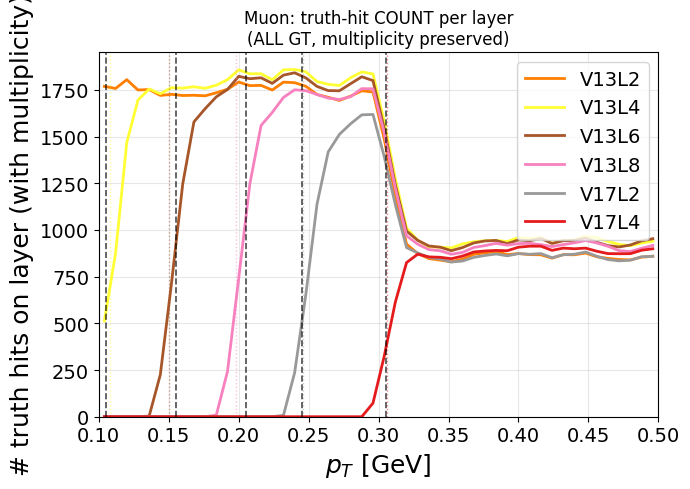

Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_truth_hits_per_particle_muon_replot.pdf


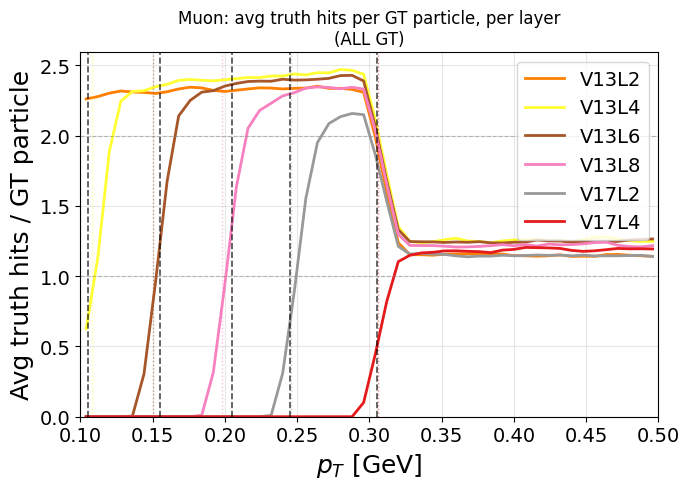

In [43]:
# self-contained guards (in case cell 3 hasn't been run in this kernel)
if "LOOP_PT" not in globals():
    LOOP_PT = 0.5 * 0.3 * 2.0 * (1020 / 1000.0)   # V17L4 looping threshold
if "dip_layers" not in globals():
    _LAYER_R = {"V8L2": 32, "V8L4": 72, "V8L6": 116, "V8L8": 172,
                "V13L2": 260, "V13L4": 360, "V13L6": 500, "V13L8": 660,
                "V17L2": 820, "V17L4": 1020}
    dip_layers = sorted(((lay, 0.5 * 0.3 * 2.0 * (R / 1000.0))
                         for lay, R in _LAYER_R.items()
                         if 0.10 <= 0.5 * 0.3 * 2.0 * (R / 1000.0) <= 0.35),
                        key=lambda kv: kv[1])
if "STAIRCASE_DIP_PT" not in globals():
    STAIRCASE_DIP_PT = []
if "overlay_dips" not in globals():
    def overlay_dips(ax, color="black", alpha=0.7, lw=1.2, label=None):
        for j, p in enumerate(STAIRCASE_DIP_PT):
            ax.axvline(p, color=color, linestyle="--", linewidth=lw,
                       alpha=alpha, zorder=4,
                       label=label if j == 0 else None)

# ── Loop-doubling check: truth-hit COUNT per layer (Muon, ALL GT) ───────────
# Same shape as the Mode-2 denominator plot above, but the numerator is the
# raw hit count (multiplicity preserved) instead of "≥1 hit on layer = 1".
# Below the V17L4 loop threshold (~0.306 GeV) inner-layer particles cross each
# reachable layer twice → ~2 hits/particle; above it, once → ~1 hit/particle.
# So the inner-layer curves should sit ~2x higher in the looping band and step
# down at ~0.306 GeV; V17L4 itself should rise from 0 at its threshold.

species = "Muon"
fig, ax = plt.subplots(figsize=FIGSIZE)
layers = sorted(allgt["truth_hits_all"][species].keys(), key=layer_radius)
layers = [l for l in layers if _keep_layer(l)]
zeros  = [0.0] * len(pt_centers)
for lay in layers:
    hits = np.array(allgt["truth_hits_all"][species].get(lay, zeros), dtype=float)
    if np.nanmax(hits) < PEAK_THRESH_ABS:
        continue
    color = layer_color(lay)
    ax.plot(pt_centers, smooth(hits, SMOOTH_WIN), "-", color=color,
            linewidth=2, label=lay)
    thr = layer_threshold(lay)
    if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
        ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.5)
overlay_dips(ax)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("# truth hits on layer (with multiplicity)", fontsize=FONT_AXIS)
ax.set_title(f"{species}: truth-hit COUNT per layer\n(ALL GT, multiplicity preserved)",
             fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / f"attribute_truth_hits_all_gt_{species.lower()}_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()

# Per-particle normalisation: same plot divided by n_with_attempt
fig, ax = plt.subplots(figsize=FIGSIZE)
n_attempt = np.array(allgt["n_with_attempt"][species], dtype=float)
mask = n_attempt > 0
for lay in layers:
    hits = np.array(allgt["truth_hits_all"][species].get(lay, zeros), dtype=float)
    if np.nanmax(hits) < PEAK_THRESH_ABS:
        continue
    avg = np.where(mask, hits / np.where(mask, n_attempt, 1), np.nan)
    color = layer_color(lay)
    ax.plot(pt_centers, smooth(avg, SMOOTH_WIN), "-", color=color,
            linewidth=2, label=lay)
    thr = layer_threshold(lay)
    if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
        ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.5)
overlay_dips(ax)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.axhline(2.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("Avg truth hits / GT particle", fontsize=FONT_AXIS)
ax.set_title(f"{species}: avg truth hits per GT particle, per layer\n(ALL GT)",
             fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / f"attribute_truth_hits_per_particle_{species.lower()}_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()


Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_n_2hit_all_gt_muon_replot.pdf


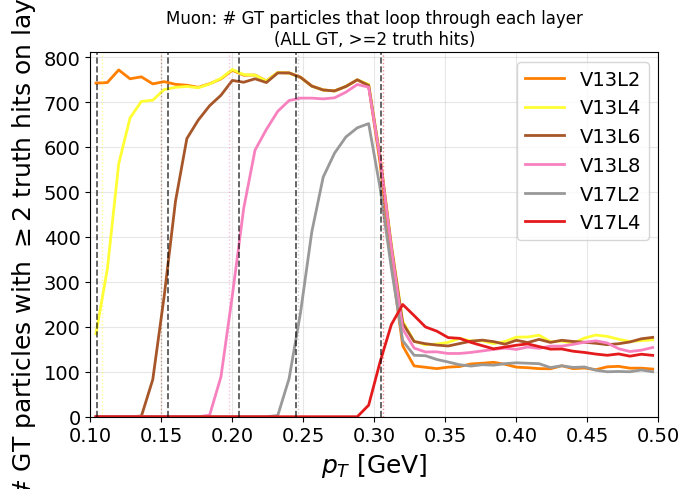

In [44]:
# self-contained guards (in case cell 3 hasn't been run in this kernel)
if "LOOP_PT" not in globals():
    LOOP_PT = 0.5 * 0.3 * 2.0 * (1020 / 1000.0)   # V17L4 looping threshold
if "dip_layers" not in globals():
    _LAYER_R = {"V8L2": 32, "V8L4": 72, "V8L6": 116, "V8L8": 172,
                "V13L2": 260, "V13L4": 360, "V13L6": 500, "V13L8": 660,
                "V17L2": 820, "V17L4": 1020}
    dip_layers = sorted(((lay, 0.5 * 0.3 * 2.0 * (R / 1000.0))
                         for lay, R in _LAYER_R.items()
                         if 0.10 <= 0.5 * 0.3 * 2.0 * (R / 1000.0) <= 0.35),
                        key=lambda kv: kv[1])
if "STAIRCASE_DIP_PT" not in globals():
    STAIRCASE_DIP_PT = []
if "overlay_dips" not in globals():
    def overlay_dips(ax, color="black", alpha=0.7, lw=1.2, label=None):
        for j, p in enumerate(STAIRCASE_DIP_PT):
            ax.axvline(p, color=color, linestyle="--", linewidth=lw,
                       alpha=alpha, zorder=4,
                       label=label if j == 0 else None)

# ── # GT particles with >=2 truth hits on a layer (Muon, ALL GT) ────────────
# Binary per particle on each layer: 1 if the particle deposited at least 2
# truth hits on that layer (i.e. crossed it twice — out + return), else 0.
# Companion to the multiplicity-preserving `truth_hits_all` plot above:
# this plot isolates how many particles actually loop back through each layer.
#
# Expectation: nonzero only between the layer's reach threshold and the
# V17L4 looping threshold (~0.306 GeV); should drop sharply to 0 above that.

species = "Muon"
fig, ax = plt.subplots(figsize=FIGSIZE)
layers = sorted(allgt["n_2hit_all"][species].keys(), key=layer_radius)
layers = [l for l in layers if _keep_layer(l)]
zeros  = [0.0] * len(pt_centers)
for lay in layers:
    n2 = np.array(allgt["n_2hit_all"][species].get(lay, zeros), dtype=float)
    if np.nanmax(n2) < PEAK_THRESH_ABS:
        continue
    color = layer_color(lay)
    ax.plot(pt_centers, smooth(n2, SMOOTH_WIN), "-", color=color,
            linewidth=2, label=lay)
    thr = layer_threshold(lay)
    if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
        ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.5)
overlay_dips(ax)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel(r"# GT particles with $\geq 2$ truth hits on layer", fontsize=FONT_AXIS)
ax.set_title(f"{species}: # GT particles that loop through each layer\n(ALL GT, >=2 truth hits)",
             fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / f"attribute_n_2hit_all_gt_{species.lower()}_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()


Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_n_1hit_all_gt_muon_replot.pdf


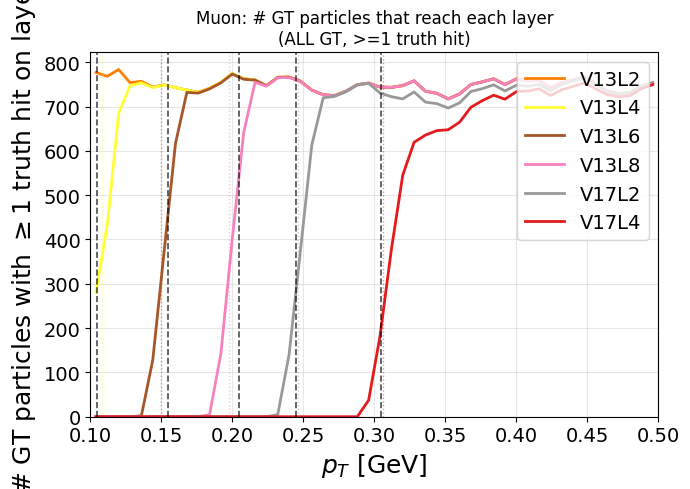

In [45]:
# self-contained guards (in case cell 3 hasn't been run in this kernel)
if "LOOP_PT" not in globals():
    LOOP_PT = 0.5 * 0.3 * 2.0 * (1020 / 1000.0)   # V17L4 looping threshold
if "dip_layers" not in globals():
    _LAYER_R = {"V8L2": 32, "V8L4": 72, "V8L6": 116, "V8L8": 172,
                "V13L2": 260, "V13L4": 360, "V13L6": 500, "V13L8": 660,
                "V17L2": 820, "V17L4": 1020}
    dip_layers = sorted(((lay, 0.5 * 0.3 * 2.0 * (R / 1000.0))
                         for lay, R in _LAYER_R.items()
                         if 0.10 <= 0.5 * 0.3 * 2.0 * (R / 1000.0) <= 0.35),
                        key=lambda kv: kv[1])
if "STAIRCASE_DIP_PT" not in globals():
    STAIRCASE_DIP_PT = []
if "overlay_dips" not in globals():
    def overlay_dips(ax, color="black", alpha=0.7, lw=1.2, label=None):
        for j, p in enumerate(STAIRCASE_DIP_PT):
            ax.axvline(p, color=color, linestyle="--", linewidth=lw,
                       alpha=alpha, zorder=4,
                       label=label if j == 0 else None)

# ── # GT particles with >=1 truth hit on a layer (Muon, ALL GT) ─────────────
# Binary per particle on each layer: 1 if the particle deposited at least one
# truth hit on that layer, else 0. Already stored in `miss_den_all` (it is
# the Mode-2 denominator). Plotting it here as the >=1 companion to the
# >=2 plot above so the two are directly comparable.

species = "Muon"
fig, ax = plt.subplots(figsize=FIGSIZE)
layers = sorted(allgt["miss_den_all"][species].keys(), key=layer_radius)
layers = [l for l in layers if _keep_layer(l)]
zeros  = [0.0] * len(pt_centers)
for lay in layers:
    n1 = np.array(allgt["miss_den_all"][species].get(lay, zeros), dtype=float)
    if np.nanmax(n1) < PEAK_THRESH_ABS:
        continue
    color = layer_color(lay)
    ax.plot(pt_centers, smooth(n1, SMOOTH_WIN), "-", color=color,
            linewidth=2, label=lay)
    thr = layer_threshold(lay)
    if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
        ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.5)
overlay_dips(ax)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel(r"# GT particles with $\geq 1$ truth hit on layer", fontsize=FONT_AXIS)
ax.set_title(f"{species}: # GT particles that reach each layer\n(ALL GT, >=1 truth hit)",
             fontsize=12)
ax.tick_params(labelsize=FONT_TICK)
ax.legend(fontsize=FONT_LEGEND, ncol=1, loc="upper right")
ax.grid(True, alpha=GRID_ALPHA)
ax.set_xlim(pt_edges[0], pt_edges[-1])
ax.set_ylim(bottom=0)
fig.tight_layout()
out = ALL_JSON.parent / f"attribute_n_1hit_all_gt_{species.lower()}_replot.pdf"
fig.savefig(out, bbox_inches="tight", dpi=DPI)
print(f"Saved: {out}")
plt.show()


Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_n_1hit_pure_vs_gated_muon_replot.pdf


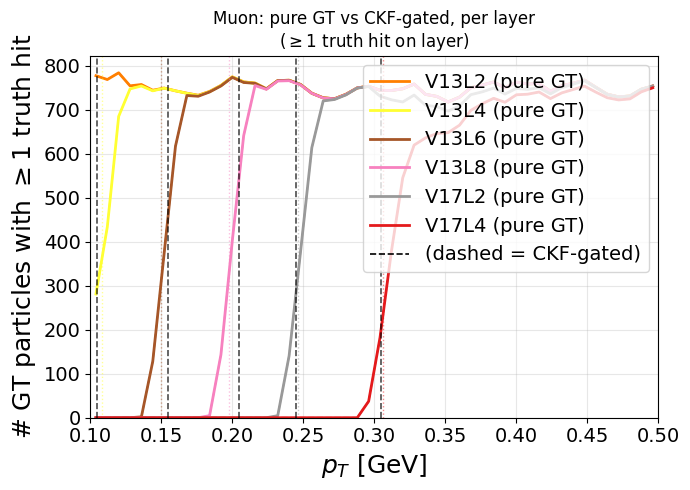

Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/attribute_n_2hit_pure_vs_gated_muon_replot.pdf


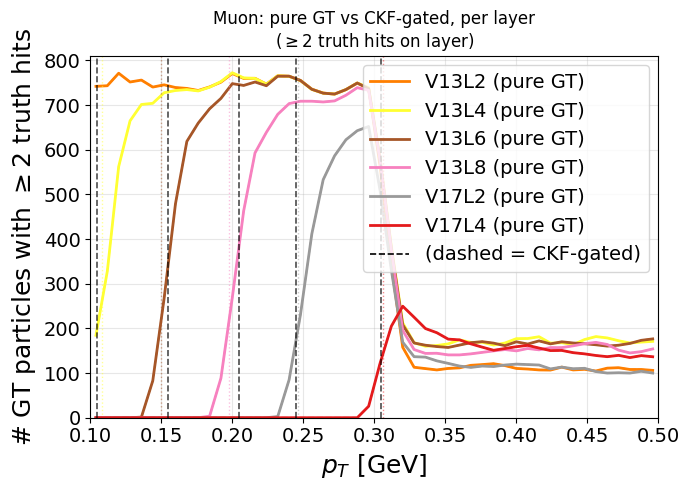

In [46]:
# self-contained guards (in case cell 3 hasn't been run in this kernel)
if "LOOP_PT" not in globals():
    LOOP_PT = 0.5 * 0.3 * 2.0 * (1020 / 1000.0)   # V17L4 looping threshold
if "dip_layers" not in globals():
    _LAYER_R = {"V8L2": 32, "V8L4": 72, "V8L6": 116, "V8L8": 172,
                "V13L2": 260, "V13L4": 360, "V13L6": 500, "V13L8": 660,
                "V17L2": 820, "V17L4": 1020}
    dip_layers = sorted(((lay, 0.5 * 0.3 * 2.0 * (R / 1000.0))
                         for lay, R in _LAYER_R.items()
                         if 0.10 <= 0.5 * 0.3 * 2.0 * (R / 1000.0) <= 0.35),
                        key=lambda kv: kv[1])
if "STAIRCASE_DIP_PT" not in globals():
    STAIRCASE_DIP_PT = []
if "overlay_dips" not in globals():
    def overlay_dips(ax, color="black", alpha=0.7, lw=1.2, label=None):
        for j, p in enumerate(STAIRCASE_DIP_PT):
            ax.axvline(p, color=color, linestyle="--", linewidth=lw,
                       alpha=alpha, zorder=4,
                       label=label if j == 0 else None)

# ── Pure-GT vs CKF-gated per-layer truth-hit counts (Muon) ──────────────────
# `miss_den_all` and `n_2hit_all` only count particles that produced a CKF
# track surviving to the matching stage (gated by n_with_attempt). Below we
# plot `n_1hit_pure_gt` and `n_2hit_pure_gt` — counts taken straight from
# hits.root with NO KF-attempt gate. If the dips at outer-layer thresholds
# are a CKF tangent-apex artefact (and not real geometry), the pure-GT
# curves should be smooth where the gated ones dip.

species = "Muon"

for crit_label, gated_key, pure_key, fname in [
    (r"$\geq 1$ truth hit",  "miss_den_all", "n_1hit_pure_gt", "n_1hit"),
    (r"$\geq 2$ truth hits", "n_2hit_all",   "n_2hit_pure_gt", "n_2hit"),
]:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    layers = sorted(allgt[pure_key][species].keys(), key=layer_radius)
    layers = [l for l in layers if _keep_layer(l)]
    zeros  = [0.0] * len(pt_centers)
    for lay in layers:
        pure  = np.array(allgt[pure_key ][species].get(lay, zeros), dtype=float)
        gated = np.array(allgt[gated_key][species].get(lay, zeros), dtype=float)
        if np.nanmax(pure) < PEAK_THRESH_ABS and np.nanmax(gated) < PEAK_THRESH_ABS:
            continue
        color = layer_color(lay)
        ax.plot(pt_centers, smooth(pure,  SMOOTH_WIN), "-",  color=color,
                linewidth=2, label=f"{lay} (pure GT)")
        ax.plot(pt_centers, smooth(gated, SMOOTH_WIN), "--", color=color,
                linewidth=1.2, alpha=0.8)
        thr = layer_threshold(lay)
        if thr is not None and pt_edges[0] <= thr <= pt_edges[-1]:
            ax.axvline(thr, color=color, linestyle=":", linewidth=1.0, alpha=0.5)
    overlay_dips(ax)
    # Add a single dummy entry to legend explaining solid vs dashed
    from matplotlib.lines import Line2D
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Line2D([], [], color="black", linestyle="--",
                          linewidth=1.2, label="(dashed = CKF-gated)"))
    ax.legend(handles=handles, fontsize=FONT_LEGEND, ncol=1, loc="upper right")
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel(f"# GT particles with {crit_label}", fontsize=FONT_AXIS)
    ax.set_title(f"{species}: pure GT vs CKF-gated, per layer\n"
                 f"({crit_label} on layer)", fontsize=12)
    ax.tick_params(labelsize=FONT_TICK)
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(pt_edges[0], pt_edges[-1])
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    out = ALL_JSON.parent / f"attribute_{fname}_pure_vs_gated_{species.lower()}_replot.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()


In [47]:
# ── Outermost-layer LOOP signature: count of GT muons / CKF attempts where the outermost-reached
# barrel layer with both an outgoing-arc (p · r̂ > 0) AND an incoming-arc (p · r̂ < 0) truth hit — a clean loop signature.
# Plots BOTH ground-truth muons (Fatras) and CKF attempts side by side.
# Sources: outgoing_only_muons.C (GT)  and  outgoing_only_kf.C (CKF)
LAYER_NAMES = ["V13L4", "V13L6", "V13L8", "V17L2", "V17L4"]
LAYER_COLORS = {"V13L4": "C0", "V13L6": "C1", "V13L8": "C2",
                "V17L2": "C4", "V17L4": "C3"}

USE_MATCHED = False
LOOP_KEY_KF = "outer_loop_count_matched" if USE_MATCHED else "outer_loop_count"
DEN_KEY_KF  = "n_total_matched"          if USE_MATCHED else "n_total"
LABEL_KF    = "ghost-filtered" if USE_MATCHED else "all CKF attempts"

# Load GT JSON (same dict that cell 22 reads into `oo`).
OO_JSON = DATA_DIR / "outgoing_only_muons.json"
with open(OO_JSON) as f:
    oo = json.load(f)
oo_centers = np.array(oo["pt_centers"])

if "outer_loop_count" not in oo:
    print(f"!! '{OO_JSON.name}' lacks 'outer_loop_count' — re-run "
          f"outgoing_only_muons.C macro to regenerate.")
elif LOOP_KEY_KF not in kf:
    print(f"!! '{LOOP_KEY_KF}' not in kf JSON — re-run outgoing_only_kf.C.")
else:
    kf_total   = np.array(kf[DEN_KEY_KF], dtype=float)
    kf_centers_local = kf_centers
    half_w_kf = 0.5 * (kf_centers_local[1] - kf_centers_local[0])
    oo_total  = np.array(oo["n_total"], dtype=float)
    half_w_oo = 0.5 * (oo_centers[1] - oo_centers[0])

    # ── Total: "any outermost layer" — overlay GT vs CKF ──
    fig, ax = plt.subplots(figsize=FIGSIZE)

    # GT (Fatras truth hits)
    gt_any = np.zeros_like(oo_total)
    for name in LAYER_NAMES:
        gt_any += np.array(oo["outer_loop_count"][name], dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        f_gt   = np.where(oo_total > 0, gt_any / oo_total, np.nan)
        err_gt = np.where(
            oo_total > 0,
            np.sqrt(np.maximum(0, f_gt * (1 - f_gt)) /
                    np.where(oo_total > 0, oo_total, 1)),
            np.nan,
        )
    ax.errorbar(oo_centers, f_gt, yerr=err_gt, xerr=half_w_oo,
                fmt="o-", color="tab:blue", markersize=3, linewidth=1.5,
                capsize=2, label="GT muons (Fatras truth hits)")

    # CKF
    kf_any = np.zeros_like(kf_total)
    for name in LAYER_NAMES:
        kf_any += np.array(kf[LOOP_KEY_KF][name], dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        f_kf   = np.where(kf_total > 0, kf_any / kf_total, np.nan)
        err_kf = np.where(
            kf_total > 0,
            np.sqrt(np.maximum(0, f_kf * (1 - f_kf)) /
                    np.where(kf_total > 0, kf_total, 1)),
            np.nan,
        )
    ax.errorbar(kf_centers_local, f_kf, yerr=err_kf, xerr=half_w_kf,
                fmt="s-", color="tab:orange", markersize=3, linewidth=1.5,
                capsize=2, label=f"CKF attempts ({LABEL_KF})")

    overlay_dips(ax)
    ymax = max(np.nanmax(f_gt) if np.any(f_gt > 0) else 0,
               np.nanmax(f_kf) if np.any(f_kf > 0) else 0)
    for lay, thr in dip_layers:
        ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0, alpha=0.4)
        ax.text(thr, max(0.02, ymax) * 0.97, lay, rotation=90, fontsize=9,
                color="dimgrey", ha="right", va="top")
    ax.axvline(LOOP_PT, color="red", linestyle="-.", linewidth=1.2, alpha=0.6,
               label=f"V17L4 loop thr ≈ {LOOP_PT:.3f}")
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("P(clean loop signature)", fontsize=FONT_AXIS)
    ax.set_title("Clean-loop fraction: ≥ 2 hits in outermost-reached layer, "
                 "with both outgoing- and incoming-arc truth hits\nGT vs CKF", fontsize=11)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, loc="lower left")
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(min(oo_centers[0], kf_centers_local[0]),
                max(oo_centers[-1], kf_centers_local[-1]))
    ax.set_ylim(0, max(0.05, ymax * 1.15))
    fig.tight_layout()
    out = KF_JSON.parent / f"loop_signature_GT_vs_CKF.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()

    # ── Per-layer (CKF) ──
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ymax_all = 0.0
    for name in LAYER_NAMES:
        cnt = np.array(kf[LOOP_KEY_KF][name], dtype=float)
        with np.errstate(divide="ignore", invalid="ignore"):
            f   = np.where(kf_total > 0, cnt / kf_total, np.nan)
            err = np.where(
                kf_total > 0,
                np.sqrt(np.maximum(0, f * (1 - f)) /
                        np.where(kf_total > 0, kf_total, 1)),
                np.nan,
            )
        if np.any(f > 0):
            ymax_all = max(ymax_all, np.nanmax(f))
        ax.errorbar(kf_centers_local, f, yerr=err, xerr=half_w_kf,
                    fmt="o-", color=LAYER_COLORS[name], markersize=3,
                    linewidth=1.5, capsize=2, label=f"CKF: {name}")
    overlay_dips(ax)
    for lay, thr in dip_layers:
        ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0, alpha=0.4)
    ax.axvline(LOOP_PT, color="red", linestyle="-.", linewidth=1.2, alpha=0.6,
               label=f"V17L4 loop thr ≈ {LOOP_PT:.3f}")
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("Fraction of CKF attempts\nwith outermost-layer loop signature",
                  fontsize=FONT_AXIS)
    ax.set_title(f"Outermost-layer LOOP signature, per-layer (CKF, {LABEL_KF})",
                 fontsize=11)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, loc="lower right", ncol=2)
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(kf_centers_local[0], kf_centers_local[-1])
    ax.set_ylim(0, max(0.05, ymax_all * 1.15))
    fig.tight_layout()
    out = KF_JSON.parent / f"kf_{LOOP_KEY_KF}_per_layer.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()

    # ── Per-layer (GT) ──
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ymax_all = 0.0
    for name in LAYER_NAMES:
        cnt = np.array(oo["outer_loop_count"][name], dtype=float)
        with np.errstate(divide="ignore", invalid="ignore"):
            f   = np.where(oo_total > 0, cnt / oo_total, np.nan)
            err = np.where(
                oo_total > 0,
                np.sqrt(np.maximum(0, f * (1 - f)) /
                        np.where(oo_total > 0, oo_total, 1)),
                np.nan,
            )
        if np.any(f > 0):
            ymax_all = max(ymax_all, np.nanmax(f))
        ax.errorbar(oo_centers, f, yerr=err, xerr=half_w_oo,
                    fmt="o-", color=LAYER_COLORS[name], markersize=3,
                    linewidth=1.5, capsize=2, label=f"GT: {name}")
    overlay_dips(ax)
    for lay, thr in dip_layers:
        ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0, alpha=0.4)
    ax.axvline(LOOP_PT, color="red", linestyle="-.", linewidth=1.2, alpha=0.6,
               label=f"V17L4 loop thr ≈ {LOOP_PT:.3f}")
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("Fraction of GT muons\nwith outermost-layer loop signature",
                  fontsize=FONT_AXIS)
    ax.set_title("Outermost-layer LOOP signature, per-layer (GT muons)",
                 fontsize=11)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, loc="lower right", ncol=2)
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(oo_centers[0], oo_centers[-1])
    ax.set_ylim(0, max(0.05, ymax_all * 1.15))
    fig.tight_layout()
    out = KF_JSON.parent / f"gt_outer_loop_count_per_layer.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()


NameError: name 'kf' is not defined

## 6c. Apex-layer arc-direction breakdown (which arc is missing?)

For tracks whose apex (outermost-reached barrel) is some layer L, the
§6 "clean loop" check passes when L saw both an outgoing-arc hit
(p · r̂ > 0) and an incoming-arc hit (p · r̂ < 0). When it fails, exactly
one of two things happened on L:

- **Missing incoming arc**: only outgoing-arc hits — the trajectory
  reached its apex but never re-crossed L on the way back (truncated
  outside the detector, lost in Fatras, or KF didn't extend to the
  return state).
- **Missing outgoing arc**: only incoming-arc hits — the apex hit's
  truth-tagged radial momentum was already inward (very-near-tangent
  geometry; the recorded surface state was on the inbound side).

`outer_only_out_count + outer_only_in_count + outer_loop_count =
outer_count`. Reads the new fields from `outgoing_only_muons.C` and
`outgoing_only_kf.C`.


Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/apex_arc_breakdown.pdf


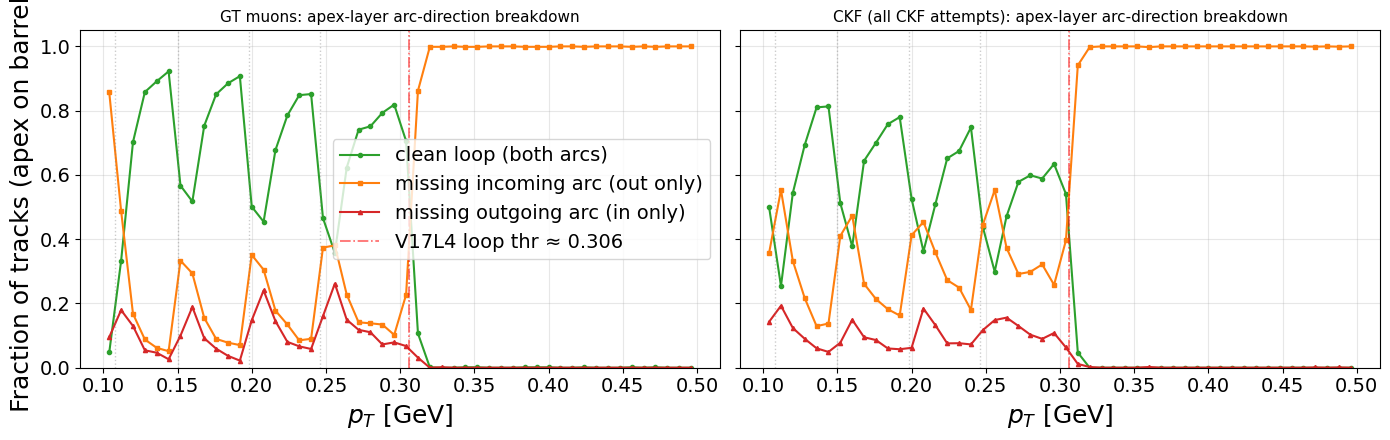

  GT muons: clean= 36.1%  only_out= 58.4%  only_in=  5.5%  (N=36445)
  CKF     : clean= 24.6%  only_out= 71.4%  only_in=  4.1%  (N=50702)


In [49]:
# Apex-layer arc-direction breakdown: of tracks whose apex is on some barrel
# layer, what fraction is "clean loop" / "missing incoming" / "missing
# outgoing"?  Sums over all apex layers. Self-contained: loads JSONs from
# DATA_DIR every run so it picks up freshly regenerated macros.

OO_JSON = DATA_DIR / "outgoing_only_muons.json"
KF_JSON = DATA_DIR / "outgoing_only_kf.json"
with open(OO_JSON) as f:
    oo = json.load(f)
with open(KF_JSON) as f:
    kf = json.load(f)
oo_centers = np.array(oo["pt_centers"])
kf_centers = np.array(kf["pt_centers"])

# Allow a Matched-only view via USE_MATCHED (default False = all CKF attempts).
USE_MATCHED = globals().get("USE_MATCHED", False)
suffix      = "_matched" if USE_MATCHED else ""
LABEL_KF    = "ghost-filtered" if USE_MATCHED else "all CKF attempts"

REQUIRED_GT = ["outer_count", "outer_loop_count",
               "outer_only_out_count", "outer_only_in_count"]
REQUIRED_KF = [k + suffix for k in REQUIRED_GT]
missing_gt  = [k for k in REQUIRED_GT if k not in oo]
missing_kf  = [k for k in REQUIRED_KF if k not in kf]

if missing_gt or missing_kf:
    print(f"!! GT JSON missing keys: {missing_gt}")
    print(f"!! KF JSON missing keys: {missing_kf}")
    print(f"   ({KF_JSON.parent})")
    print("Re-run outgoing_only_muons.C and outgoing_only_kf.C macros.")
else:
    LAYER_NAMES = ["V13L4", "V13L6", "V13L8", "V17L2", "V17L4"]

    def stack(d, key):
        return np.sum([np.array(d[key][n], dtype=float) for n in LAYER_NAMES],
                      axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
    panels = [(axes[0], oo, oo_centers, "GT muons", ""),
              (axes[1], kf, kf_centers, f"CKF ({LABEL_KF})", suffix)]
    for ax, src, centers, title, sfx in panels:
        outer    = stack(src, "outer_count" + sfx)
        clean    = stack(src, "outer_loop_count" + sfx)
        only_out = stack(src, "outer_only_out_count" + sfx)
        only_in  = stack(src, "outer_only_in_count" + sfx)
        with np.errstate(divide="ignore", invalid="ignore"):
            f_clean    = np.where(outer > 0, clean / outer,    np.nan)
            f_only_out = np.where(outer > 0, only_out / outer, np.nan)
            f_only_in  = np.where(outer > 0, only_in / outer,  np.nan)
        ax.plot(centers, f_clean,    "o-", color="tab:green",
                ms=3, lw=1.5, label="clean loop (both arcs)")
        ax.plot(centers, f_only_out, "s-", color="tab:orange",
                ms=3, lw=1.5, label="missing incoming arc (out only)")
        ax.plot(centers, f_only_in,  "^-", color="tab:red",
                ms=3, lw=1.5, label="missing outgoing arc (in only)")
        for lay, thr in dip_layers:
            ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0,
                       alpha=0.4)
        ax.axvline(LOOP_PT, color="red", linestyle="-.", linewidth=1.2,
                   alpha=0.6, label=f"V17L4 loop thr ≈ {LOOP_PT:.3f}")
        ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
        ax.set_title(f"{title}: apex-layer arc-direction breakdown",
                     fontsize=11)
        ax.tick_params(labelsize=FONT_TICK)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=GRID_ALPHA)
    axes[0].set_ylabel("Fraction of tracks (apex on barrel)",
                       fontsize=FONT_AXIS)
    axes[0].legend(fontsize=FONT_LEGEND, loc="best")
    fig.tight_layout()
    out = KF_JSON.parent / "apex_arc_breakdown.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()

    # Headline numbers integrated over pT.
    for label, src, sfx in [("GT muons", oo, ""), ("CKF", kf, suffix)]:
        outer    = sum(stack(src, "outer_count" + sfx))
        clean    = sum(stack(src, "outer_loop_count" + sfx))
        only_out = sum(stack(src, "outer_only_out_count" + sfx))
        only_in  = sum(stack(src, "outer_only_in_count" + sfx))
        if outer > 0:
            print(f"  {label:<8s}: clean={clean/outer*100:5.1f}%  "
                  f"only_out={only_out/outer*100:5.1f}%  "
                  f"only_in={only_in/outer*100:5.1f}%  "
                  f"(N={int(outer)})")


Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/gt_loop_count_per_layer.pdf


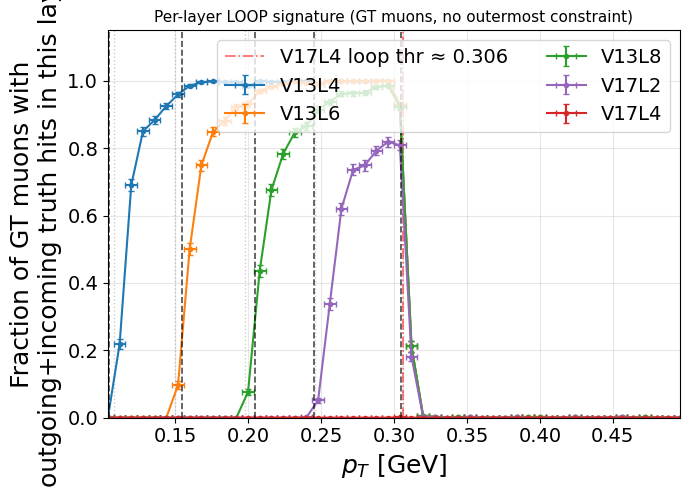

Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_500event/kf_loop_count_per_layer.pdf


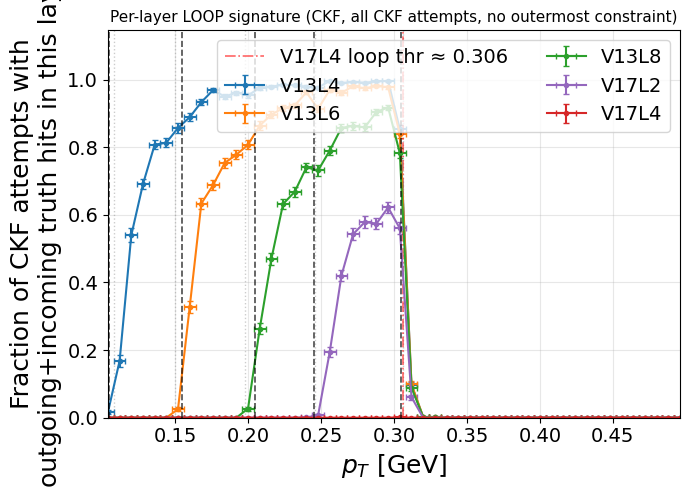

In [50]:
# ── Per-layer LOOP signature (NO outermost constraint): for each barrel
# layer, what fraction of GT muons / CKF attempts have ≥ 2 truth hits in
# THAT layer record both an outgoing-arc (p · r̂ > 0) and an incoming-arc (p · r̂ < 0) truth hit?  Same criterion as the previous
# cell, but now we don't require the layer to be the trajectory's apex.
# Reads `loop_count` (GT, from outgoing_only_muons.C) and `loop_count`
# / `loop_count_matched` (CKF, from outgoing_only_kf.C).
LAYER_NAMES = ["V13L4", "V13L6", "V13L8", "V17L2", "V17L4"]
LAYER_COLORS = {"V13L4": "C0", "V13L6": "C1", "V13L8": "C2",
                "V17L2": "C4", "V17L4": "C3"}

USE_MATCHED = False
LOOP_KEY_KF = "loop_count_matched" if USE_MATCHED else "loop_count"
DEN_KEY_KF  = "n_total_matched"    if USE_MATCHED else "n_total"
LABEL_KF    = "ghost-filtered" if USE_MATCHED else "all CKF attempts"

OO_JSON = DATA_DIR / "outgoing_only_muons.json"
with open(OO_JSON) as f:
    oo = json.load(f)
oo_centers = np.array(oo["pt_centers"])

if "loop_count" not in oo:
    print(f"!! '{OO_JSON.name}' lacks 'loop_count' — re-run "
          f"outgoing_only_muons.C macro to regenerate.")
elif LOOP_KEY_KF not in kf:
    print(f"!! '{LOOP_KEY_KF}' not in kf JSON — re-run outgoing_only_kf.C.")
else:
    kf_total   = np.array(kf[DEN_KEY_KF], dtype=float)
    kf_centers_local = kf_centers
    half_w_kf = 0.5 * (kf_centers_local[1] - kf_centers_local[0])
    oo_total  = np.array(oo["n_total"], dtype=float)
    half_w_oo = 0.5 * (oo_centers[1] - oo_centers[0])

    # ── per-layer GT ──
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ymax_all = 0.0
    for name in LAYER_NAMES:
        cnt = np.array(oo["loop_count"][name], dtype=float)
        with np.errstate(divide="ignore", invalid="ignore"):
            f   = np.where(oo_total > 0, cnt / oo_total, np.nan)
            err = np.where(
                oo_total > 0,
                np.sqrt(np.maximum(0, f * (1 - f)) /
                        np.where(oo_total > 0, oo_total, 1)),
                np.nan,
            )
        if np.any(f > 0):
            ymax_all = max(ymax_all, np.nanmax(f))
        ax.errorbar(oo_centers, f, yerr=err, xerr=half_w_oo,
                    fmt="o-", color=LAYER_COLORS[name], markersize=3,
                    linewidth=1.5, capsize=2, label=name)
    overlay_dips(ax)
    for lay, thr in dip_layers:
        ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0, alpha=0.4)
    ax.axvline(LOOP_PT, color="red", linestyle="-.", linewidth=1.2, alpha=0.6,
               label=f"V17L4 loop thr ≈ {LOOP_PT:.3f}")
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("Fraction of GT muons with\noutgoing+incoming truth hits in this layer",
                  fontsize=FONT_AXIS)
    ax.set_title("Per-layer LOOP signature (GT muons, no outermost constraint)",
                 fontsize=11)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, loc="upper right", ncol=2)
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(oo_centers[0], oo_centers[-1])
    ax.set_ylim(0, max(0.05, ymax_all * 1.15))
    fig.tight_layout()
    out = KF_JSON.parent / "gt_loop_count_per_layer.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()

    # ── per-layer CKF ──
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ymax_all = 0.0
    for name in LAYER_NAMES:
        cnt = np.array(kf[LOOP_KEY_KF][name], dtype=float)
        with np.errstate(divide="ignore", invalid="ignore"):
            f   = np.where(kf_total > 0, cnt / kf_total, np.nan)
            err = np.where(
                kf_total > 0,
                np.sqrt(np.maximum(0, f * (1 - f)) /
                        np.where(kf_total > 0, kf_total, 1)),
                np.nan,
            )
        if np.any(f > 0):
            ymax_all = max(ymax_all, np.nanmax(f))
        ax.errorbar(kf_centers_local, f, yerr=err, xerr=half_w_kf,
                    fmt="o-", color=LAYER_COLORS[name], markersize=3,
                    linewidth=1.5, capsize=2, label=name)
    overlay_dips(ax)
    for lay, thr in dip_layers:
        ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0, alpha=0.4)
    ax.axvline(LOOP_PT, color="red", linestyle="-.", linewidth=1.2, alpha=0.6,
               label=f"V17L4 loop thr ≈ {LOOP_PT:.3f}")
    ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
    ax.set_ylabel("Fraction of CKF attempts with\noutgoing+incoming truth hits in this layer",
                  fontsize=FONT_AXIS)
    ax.set_title(f"Per-layer LOOP signature (CKF, {LABEL_KF}, no outermost constraint)",
                 fontsize=11)
    ax.tick_params(labelsize=FONT_TICK)
    ax.legend(fontsize=FONT_LEGEND, loc="upper right", ncol=2)
    ax.grid(True, alpha=GRID_ALPHA)
    ax.set_xlim(kf_centers_local[0], kf_centers_local[-1])
    ax.set_ylim(0, max(0.05, ymax_all * 1.15))
    fig.tight_layout()
    out = KF_JSON.parent / f"kf_{LOOP_KEY_KF}_per_layer.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out}")
    plt.show()


Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_files/gt_vs_kf_counts_replot.pdf


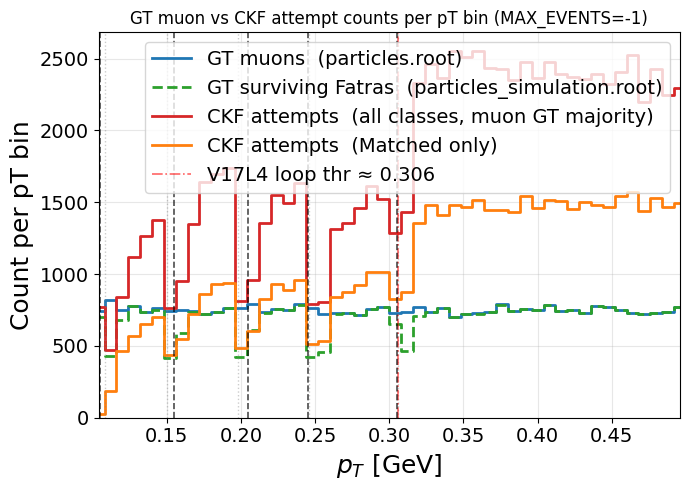

Saved: /data/alice/bkuipers/acts/output_examples/300_mixed_files/kf_per_gt_muon_ratio_replot.pdf


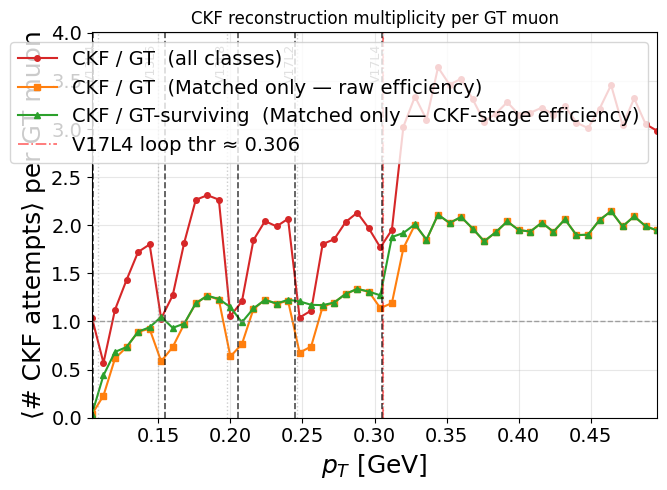

In [ ]:
# # ── GT muon count vs CKF attempt count per pT bin ──────────────────────────
# # Three GT/CKF curves per pT bin (all on the shared 50-bin pT axis 0.1–0.5):
# #   gt_counts      = oo["n_total"]                       (every gun-fired muon)
# #   gt_surviving   = gt_counts - drop["n_dropped"]       (GT actually present
# #                                                         in particles_simulation.root,
# #                                                         i.e. propagated to completion)
# #   kf_counts_all  = kf["n_total"]          (CKF, muon GT majority, all classes)
# #   kf_counts_mat  = kf["n_total_matched"]  (CKF, Matched only)
# #
# # Ratio interpretation (per pT bin):
# #   ratio > 1  ⇒ duplicate ghost branches dominate
# #   ratio < 1  ⇒ efficiency loss
# # The "Matched / surviving GT" curve is the cleanest CKF efficiency: every GT
# # in its denominator was actually transported by Fatras, so any deficit there
# # is a CKF-stage loss, not a Fatras drop.

# gt_counts     = np.array(oo["n_total"], dtype=float)
# gt_surviving  = gt_counts - np.array(drop["n_dropped"], dtype=float)
# kf_counts_all = np.array(kf["n_total"], dtype=float)
# kf_counts_mat = np.array(kf["n_total_matched"], dtype=float)
# counts_centers = oo_centers
# half_w = 0.5 * (counts_centers[1] - counts_centers[0])

# # ── Counts overlay ──
# fig, ax = plt.subplots(figsize=FIGSIZE)
# ax.step(counts_centers, gt_counts, where="mid", color="C0", linewidth=2,
#         label="GT muons  (particles.root)")
# ax.step(counts_centers, gt_surviving, where="mid", color="C2", linewidth=2,
#         linestyle="--", label="GT surviving Fatras  (particles_simulation.root)")
# ax.step(counts_centers, kf_counts_all, where="mid", color="C3", linewidth=2,
#         label="CKF attempts  (all classes, muon GT majority)")
# ax.step(counts_centers, kf_counts_mat, where="mid", color="C1", linewidth=2,
#         label="CKF attempts  (Matched only)")
# overlay_dips(ax)
# for lay, thr in dip_layers:
#     ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0, alpha=0.4)
# ax.axvline(LOOP_PT, color="red", linestyle="-.", linewidth=1.2, alpha=0.6,
#            label=f"V17L4 loop thr ≈ {LOOP_PT:.3f}")
# ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
# ax.set_ylabel("Count per pT bin", fontsize=FONT_AXIS)
# ax.set_title(f"GT muon vs CKF attempt counts per pT bin "
#              f"(MAX_EVENTS={kf['max_events']})", fontsize=12)
# ax.tick_params(labelsize=FONT_TICK)
# ax.legend(fontsize=FONT_LEGEND, loc="upper right")
# ax.grid(True, alpha=GRID_ALPHA)
# ax.set_xlim(counts_centers[0], counts_centers[-1])
# ax.set_ylim(bottom=0)
# fig.tight_layout()
# out = KF_JSON.parent / "gt_vs_kf_counts_replot.pdf"
# fig.savefig(out, bbox_inches="tight", dpi=DPI)
# print(f"Saved: {out}")
# plt.show()

# # ── Ratio: avg # CKF attempts per GT muon ──
# with np.errstate(divide="ignore", invalid="ignore"):
#     ratio_all      = np.where(gt_counts    > 0, kf_counts_all / gt_counts,    np.nan)
#     ratio_mat      = np.where(gt_counts    > 0, kf_counts_mat / gt_counts,    np.nan)
#     ratio_mat_surv = np.where(gt_surviving > 0, kf_counts_mat / gt_surviving, np.nan)

# fig, ax = plt.subplots(figsize=FIGSIZE)
# ax.plot(counts_centers, ratio_all, "o-", color="C3", markersize=4, linewidth=1.5,
#         label="CKF / GT  (all classes)")
# ax.plot(counts_centers, ratio_mat, "s-", color="C1", markersize=4, linewidth=1.5,
#         label="CKF / GT  (Matched only — raw efficiency)")
# ax.plot(counts_centers, ratio_mat_surv, "^-", color="C2", markersize=4, linewidth=1.5,
#         label="CKF / GT-surviving  (Matched only — CKF-stage efficiency)")
# ax.axhline(1.0, color="grey", linestyle="--", linewidth=1.0, alpha=0.7)
# overlay_dips(ax)
# ymax_r = max(np.nanmax(ratio_all)      if np.any(ratio_all > 0)      else 1.0,
#              np.nanmax(ratio_mat)      if np.any(ratio_mat > 0)      else 1.0,
#              np.nanmax(ratio_mat_surv) if np.any(ratio_mat_surv > 0) else 1.0,
#              1.2) * 1.1
# for lay, thr in dip_layers:
#     ax.axvline(thr, color="grey", linestyle=":", linewidth=1.0, alpha=0.4)
#     ax.text(thr, ymax_r * 0.97, lay, rotation=90,
#             fontsize=9, color="dimgrey", ha="right", va="top")
# ax.axvline(LOOP_PT, color="red", linestyle="-.", linewidth=1.2, alpha=0.6,
#            label=f"V17L4 loop thr ≈ {LOOP_PT:.3f}")
# ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
# ax.set_ylabel("⟨# CKF attempts⟩ per GT muon", fontsize=FONT_AXIS)
# ax.set_title("CKF reconstruction multiplicity per GT muon", fontsize=12)
# ax.tick_params(labelsize=FONT_TICK)
# ax.legend(fontsize=FONT_LEGEND, loc="upper right")
# ax.grid(True, alpha=GRID_ALPHA)
# ax.set_xlim(counts_centers[0], counts_centers[-1])
# ax.set_ylim(0, ymax_r)
# fig.tight_layout()
# out = KF_JSON.parent / "kf_per_gt_muon_ratio_replot.pdf"
# fig.savefig(out, bbox_inches="tight", dpi=DPI)
# print(f"Saved: {out}")
# plt.show()
